## Import Libraries

In [1]:
import os
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer

In [2]:
#for processing and Feature Engineering

from sklearn.impute import(
    SimpleImputer,
    KNNImputer
)

from sklearn.feature_selection import(
    SelectKBest,
    SelectPercentile,
    RFE,
    RFECV,
    VarianceThreshold
)

from sklearn.preprocessing import(
    OneHotEncoder,
    MinMaxScaler,
    RobustScaler,
    Normalizer,
    PolynomialFeatures,
    OrdinalEncoder,
    LabelEncoder,
    KBinsDiscretizer,
    FunctionTransformer,
    StandardScaler
)

#model selection and evaluation

from sklearn.model_selection import(
    train_test_split,
    cross_val_predict,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    KFold,
    cross_validate
)

# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    confusion_matrix,
    r2_score,
    classification_report,
    f1_score,
    recall_score,
    explained_variance_score,
    precision_score
)


#for Regression

from sklearn.linear_model import(
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    SGDRegressor,
    PassiveAggressiveRegressor
)

from sklearn.tree import(
    DecisionTreeRegressor,
)
 
from sklearn.ensemble import(
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor
)

from sklearn.svm import(
    SVR,
    LinearSVR
)

from sklearn.neighbors import(
    KNeighborsRegressor,
)

from sklearn.neural_network import(
    MLPRegressor,
    _multilayer_perceptron
)

#for classification
from sklearn.linear_model import(
    LogisticRegression,
    RidgeClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import(
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)

from sklearn.svm import(
    SVC,
    LinearSVC,
    NuSVC
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import(
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)

from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import(
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)

from sklearn.impute import IterativeImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

import scipy.stats as stats

from scipy.stats import(
    anderson,
    jarque_bera,
    shapiro,
    normaltest,
    kstest
)

from statsmodels.stats.diagnostic import lilliefors

from scipy.stats import zscore

from sklearn.feature_extraction import FeatureHasher

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings('ignore')

## Loading Datasets

In [3]:
import pandas as pd
path=os.path.join('..','data', 'raw', 'used_cars.csv')
df = pd.read_csv(path)
print(path)

..\data\raw\used_cars.csv


In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
df.shape

(4009, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## Data Cleaning

In [7]:
df['milage']=(
    df['milage']
    .str.replace('mi.', '')
    .str.replace(',', '')
    .astype(float)
)

In [8]:
df['milage'].dtype

dtype('float64')

In [9]:
df['price']=(
    df['price']
    .str.replace('$', '')
    .str.replace(',', '')
    .astype(float)
)

In [10]:
df['price'].dtype

dtype('float64')

In [11]:
df['Accident_Occured']=(
    df['accident']
    .apply(lambda x: "NO" if x=="None reported" else "YES")
)

In [12]:
df.drop('accident', axis=1, inplace=True)

In [13]:
df['Engine_Capacity']=(
    df['engine']
    .str.extract(r'(\d+\.\d+L | \d+L | \d+\.\d+\s+Liter | \d+\s+Liter)')
)

In [14]:
df['Horse_Power']=(
    df['engine']
    .str.extract(r'(\d+\.\d+HP | \d+HP)', flags=re.IGNORECASE)
)

In [15]:
df['Engine_Capacity']=(
    df['Engine_Capacity']
    .str.replace('Litre', '')
    .str.replace('L', '')
    .astype(float)
)

In [16]:
df['Horse_Power']=(
    df['Horse_Power']
    .str.replace('HP', '')
    .astype(float)
)

In [17]:
df.duplicated().sum()

0

In [18]:
print(f'Memory Consumption: {round(df.memory_usage(deep=True).sum()/(1024*1024),2)}')

Memory Consumption: 2.48


In [19]:
df.isnull().sum()

brand                 0
model                 0
model_year            0
milage                0
fuel_type           170
engine                0
transmission          0
ext_col               0
int_col               0
clean_title         596
price                 0
Accident_Occured      0
Engine_Capacity     398
Horse_Power         808
dtype: int64

In [20]:
missing_info={}
for col in df.columns:
    if df[col].isnull().sum()>0:
        missing_count= df[col].isnull().sum()/len(df)*100
        missing_info[col]=round(missing_count, 2)

print("\nThe missing columns with perentage:\n")
for col,perc in missing_info.items():
    print(f'{col} : {perc}%')


The missing columns with perentage:

fuel_type : 4.24%
clean_title : 14.87%
Engine_Capacity : 9.93%
Horse_Power : 20.15%


In [21]:
missing = df.isna().mean()*100
missing = missing[missing>0].sort_values(ascending=False)

print(missing)

Horse_Power        20.154652
clean_title        14.866550
Engine_Capacity     9.927663
fuel_type           4.240459
dtype: float64


In [22]:
def missing_report(df):
    missing = df.isna().sum()
    percent = (missing/len(df))*100
    
    report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': percent
    })
    
    return report[report['Missing Count']>0]

missing_report(df)

,Missing Count,Missing %
fuel_type,170,4.240459
clean_title,596,14.866550
Engine_Capacity,398,9.927663
Horse_Power,808,20.154652


In [23]:
missing_hp_df=df[df['Horse_Power'].isna()]

In [24]:
#pd.set_option('display.max_rows',None)
pd.reset_option('display.max_rows')
missing_hp_df[['brand','engine', 'fuel_type', 'Horse_Power']]

,brand,engine,fuel_type,Horse_Power
1,Hyundai,3.8L V6 24V GDI DOHC,Gasoline,NaN
2,Lexus,3.5 Liter DOHC,Gasoline,NaN
4,Audi,2.0L I4 16V GDI DOHC Turbo,Gasoline,NaN
5,Acura,2.4 Liter,Gasoline,NaN
10,Land,V6,Gasoline,NaN
...,...,...,...,...
3971,Buick,2.0L I4 16V GDI DOHC Turbo,Gasoline,NaN
3984,Toyota,–,–,NaN
3991,Porsche,4.0L V8 32V GDI DOHC Twin Turbo,Gasoline,NaN
4004,Bentley,6.0L W12 48V PDI DOHC Twin Turbo,Gasoline,NaN


In [25]:
missing_hp_df[['brand','engine', 'fuel_type', 'Horse_Power']]

,brand,engine,fuel_type,Horse_Power
1,Hyundai,3.8L V6 24V GDI DOHC,Gasoline,NaN
2,Lexus,3.5 Liter DOHC,Gasoline,NaN
4,Audi,2.0L I4 16V GDI DOHC Turbo,Gasoline,NaN
5,Acura,2.4 Liter,Gasoline,NaN
10,Land,V6,Gasoline,NaN
...,...,...,...,...
3971,Buick,2.0L I4 16V GDI DOHC Turbo,Gasoline,NaN
3984,Toyota,–,–,NaN
3991,Porsche,4.0L V8 32V GDI DOHC Twin Turbo,Gasoline,NaN
4004,Bentley,6.0L W12 48V PDI DOHC Twin Turbo,Gasoline,NaN


In [26]:
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [27]:
missing_hp_df=df[df['Engine_Capacity'].isna()]


In [28]:
missing_hp_df[['brand','engine', 'fuel_type', 'Horse_Power', 'Engine_Capacity']]

,brand,engine,fuel_type,Horse_Power,Engine_Capacity
2,Lexus,3.5 Liter DOHC,Gasoline,NaN,NaN
5,Acura,2.4 Liter,Gasoline,NaN,NaN
9,Tesla,534.0HP Electric Motor Electric Fuel System,NaN,534.0,NaN
10,Land,V6,Gasoline,NaN,NaN
14,Jaguar,2.0 Liter Supercharged,Gasoline,NaN,NaN
...,...,...,...,...,...
3932,Tesla,778.0HP Electric Motor Electric Fuel System,NaN,778.0,NaN
3952,Dodge,–,–,NaN,NaN
3961,Tesla,Electric,NaN,NaN,NaN
3984,Toyota,–,–,NaN,NaN


In [29]:
df['clean_title']=df['clean_title'].fillna('unknown')

In [30]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,54598.0,NO,NaN,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,NO,2.0,NaN


In [31]:
rare_brands = df['brand'].value_counts()
rare_brands = rare_brands[rare_brands < 5].index

df_rare = df[df['brand'].isin(rare_brands)][['brand','model','model_year']]

df_rare

,brand,model,model_year
44,Lucid,Air Grand Touring,2022
68,Lucid,Air Grand Touring,2022
129,Lucid,Air Pure,2023
229,Bugatti,Veyron 16.4 Grand Sport,2011
236,Polestar,2 Launch Edition,2021
537,Lotus,Evora 400 Base,2017
719,Karma,Revero Base,2018
812,Saab,9-3 SE,2002
818,Mercury,Marauder Base,2004
833,Mercury,Marauder Base,2003


In [32]:
df[df['brand'].map(df['brand'].value_counts()) < 5][['brand','model','model_year']]

,brand,model,model_year
44,Lucid,Air Grand Touring,2022
68,Lucid,Air Grand Touring,2022
129,Lucid,Air Pure,2023
229,Bugatti,Veyron 16.4 Grand Sport,2011
236,Polestar,2 Launch Edition,2021
537,Lotus,Evora 400 Base,2017
719,Karma,Revero Base,2018
812,Saab,9-3 SE,2002
818,Mercury,Marauder Base,2004
833,Mercury,Marauder Base,2003


In [33]:
Numerical_Columns = df.select_dtypes(include=['number', 'int32', 'int64','float32', 'float64']).columns
Categorical_Columns = df.select_dtypes(include=['object', 'category']).columns


In [34]:
df[Numerical_Columns].head()

,model_year,milage,price,Engine_Capacity,Horse_Power
0,2013,51000.0,10300.0,3.7,300.0
1,2021,34742.0,38005.0,3.8,NaN
2,2022,22372.0,54598.0,NaN,NaN
3,2015,88900.0,15500.0,3.5,354.0
4,2021,9835.0,34999.0,2.0,NaN


In [35]:
df[Categorical_Columns].head()

,brand,model,fuel_type,engine,transmission,ext_col,int_col,clean_title,Accident_Occured
0,Ford,Utility Police Interceptor Base,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,YES
1,Hyundai,Palisade SEL,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,YES
2,Lexus,RX 350 RX 350,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,NO
3,INFINITI,Q50 Hybrid Sport,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,NO
4,Audi,Q3 45 S line Premium Plus,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,NO


### Handling Missing Columns

In [36]:
df[Numerical_Columns].isnull().sum()

model_year           0
milage               0
price                0
Engine_Capacity    398
Horse_Power        808
dtype: int64

In [37]:
missing_info={}
for col in Numerical_Columns:
    if df[col].isnull().sum()>0:
        missing_count= df[col].isnull().sum()/len(df)*100
        missing_info[col]=round(missing_count, 2)

print("\nThe missing Numerical columns with perentage:\n")
for col,perc in missing_info.items():
    print(f'{col} : {perc}%')


The missing Numerical columns with perentage:

Engine_Capacity : 9.93%
Horse_Power : 20.15%


#### Box Plot of Numerical Columns

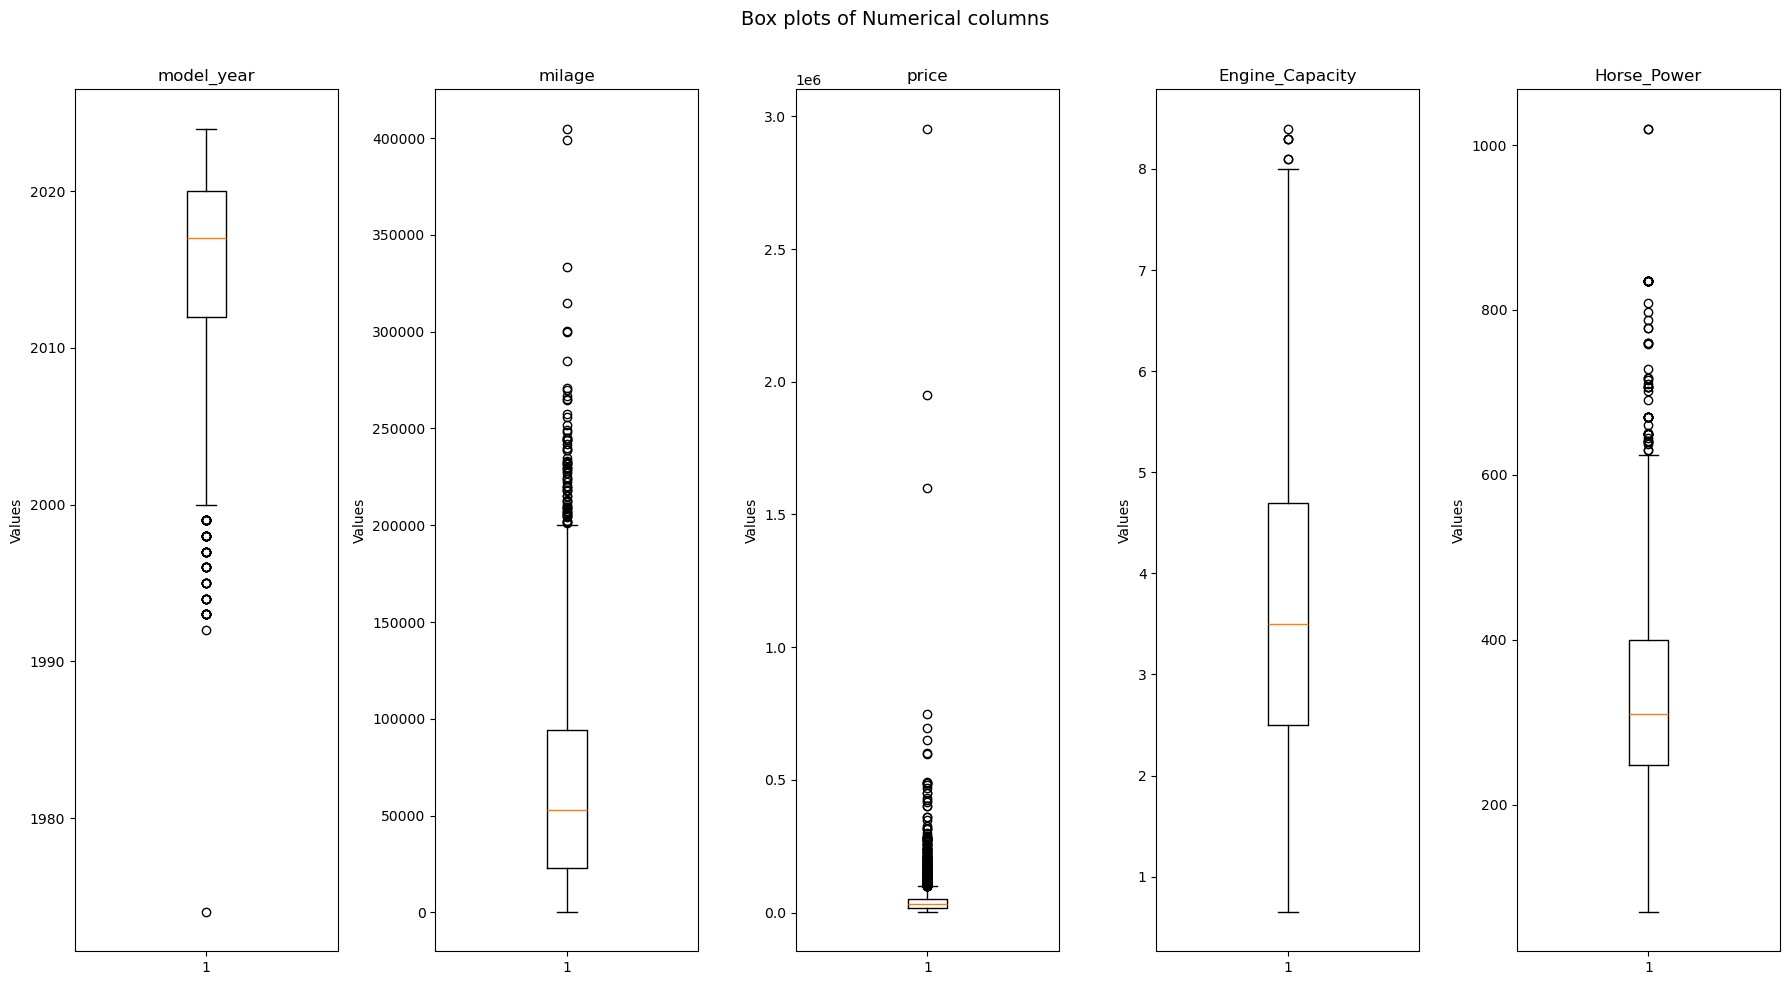

In [38]:
fig, axes=plt.subplots(1,5, figsize=(18,10))

for i, cols in enumerate(Numerical_Columns):
    axes[i].boxplot(df[cols].dropna())
    axes[i].set_title(cols)
    axes[i].set_ylabel('Values')

plt.suptitle("Box plots of Numerical columns", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [39]:
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity', 'engine']]

,Engine_Capacity,engine
2,NaN,3.5 Liter DOHC
5,NaN,2.4 Liter
9,NaN,534.0HP Electric Motor Electric Fuel System
10,NaN,V6
14,NaN,2.0 Liter Supercharged
...,...,...
3932,NaN,778.0HP Electric Motor Electric Fuel System
3952,NaN,–
3961,NaN,Electric
3984,NaN,–


#### If the vehicle is electric → replace missing engine capacity with 0. Otherwise keep original values.

The ~ means NOT:
This flips values:

False → True

True → False


So now:

True → non-electric cars

False → electric cars


df['Engine_Capacity'].where(condition, replacement)

keep value where condition is True

replace where condition is False

In [40]:
df['Engine_Capacity']=df['Engine_Capacity'].where(
    ~df['engine'].str.contains('Electric Motor Electric Fuel System', case=False, na=False), 
    df['Engine_Capacity'].fillna(0))

In [41]:
df.loc[df['Engine_Capacity'].isnull(), ['Engine_Capacity', 'engine', 'brand', 'fuel_type', 'model']]

,Engine_Capacity,engine,brand,fuel_type,model
2,NaN,3.5 Liter DOHC,Lexus,Gasoline,RX 350 RX 350
5,NaN,2.4 Liter,Acura,Gasoline,ILX 2.4L
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
14,NaN,2.0 Liter Supercharged,Jaguar,Gasoline,F-TYPE
22,NaN,3.0 Liter Turbo,BMW,Gasoline,440 Gran Coupe 440i xDrive
...,...,...,...,...,...
3922,NaN,–,Mazda,–,Protege DX
3952,NaN,–,Dodge,–,Ram 3500 Quad Cab DRW
3961,NaN,Electric,Tesla,NaN,Model 3 Long Range
3984,NaN,–,Toyota,–,Land Cruiser Base


In [42]:
df['Engine_Capacity']=df['Engine_Capacity'].where(
    ~df['engine'].str.contains('Dual Motor - Standard', case=False, na=False), 
    df['Engine_Capacity'].fillna(0))

In [43]:
df.loc[df['Engine_Capacity'].isnull(), ['Engine_Capacity', 'engine', 'brand', 'fuel_type', 'model']]

,Engine_Capacity,engine,brand,fuel_type,model
2,NaN,3.5 Liter DOHC,Lexus,Gasoline,RX 350 RX 350
5,NaN,2.4 Liter,Acura,Gasoline,ILX 2.4L
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
14,NaN,2.0 Liter Supercharged,Jaguar,Gasoline,F-TYPE
22,NaN,3.0 Liter Turbo,BMW,Gasoline,440 Gran Coupe 440i xDrive
...,...,...,...,...,...
3922,NaN,–,Mazda,–,Protege DX
3952,NaN,–,Dodge,–,Ram 3500 Quad Cab DRW
3961,NaN,Electric,Tesla,NaN,Model 3 Long Range
3984,NaN,–,Toyota,–,Land Cruiser Base


In [44]:
print(f"The missing percentage in the Engine_Capacity is: {round(df['Engine_Capacity'].isna().sum()/len(df)*100,2)}%")

The missing percentage in the Engine_Capacity is: 6.39%


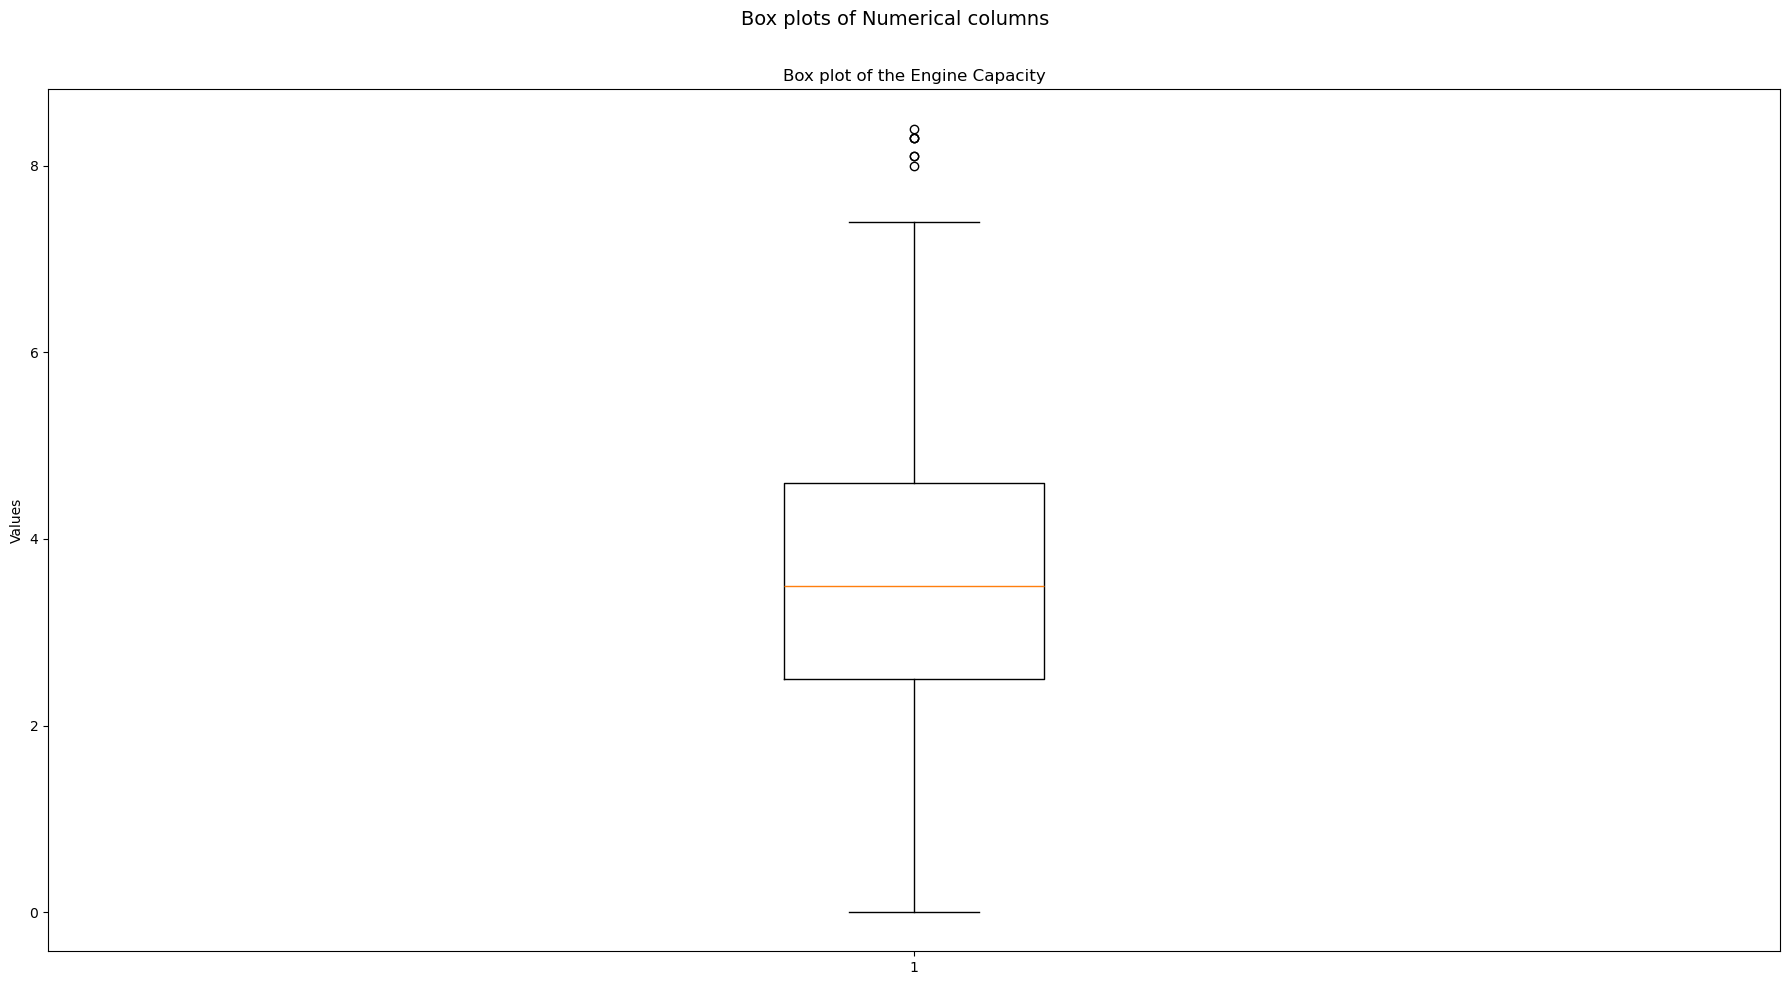

In [45]:
fig, axes=plt.subplots(figsize=(18,10))

axes.boxplot(df['Engine_Capacity'].dropna())
axes.set_title('Box plot of the Engine Capacity')
axes.set_ylabel('Values')
plt.suptitle("Box plots of Numerical columns", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [46]:
df['Engine_Capacity']=df['Engine_Capacity'].fillna(df['Engine_Capacity'].median())

In [47]:
df.loc[df['Engine_Capacity'].isnull(), ['Engine_Capacity', 'engine', 'brand', 'fuel_type', 'model']]

,Engine_Capacity,engine,brand,fuel_type,model


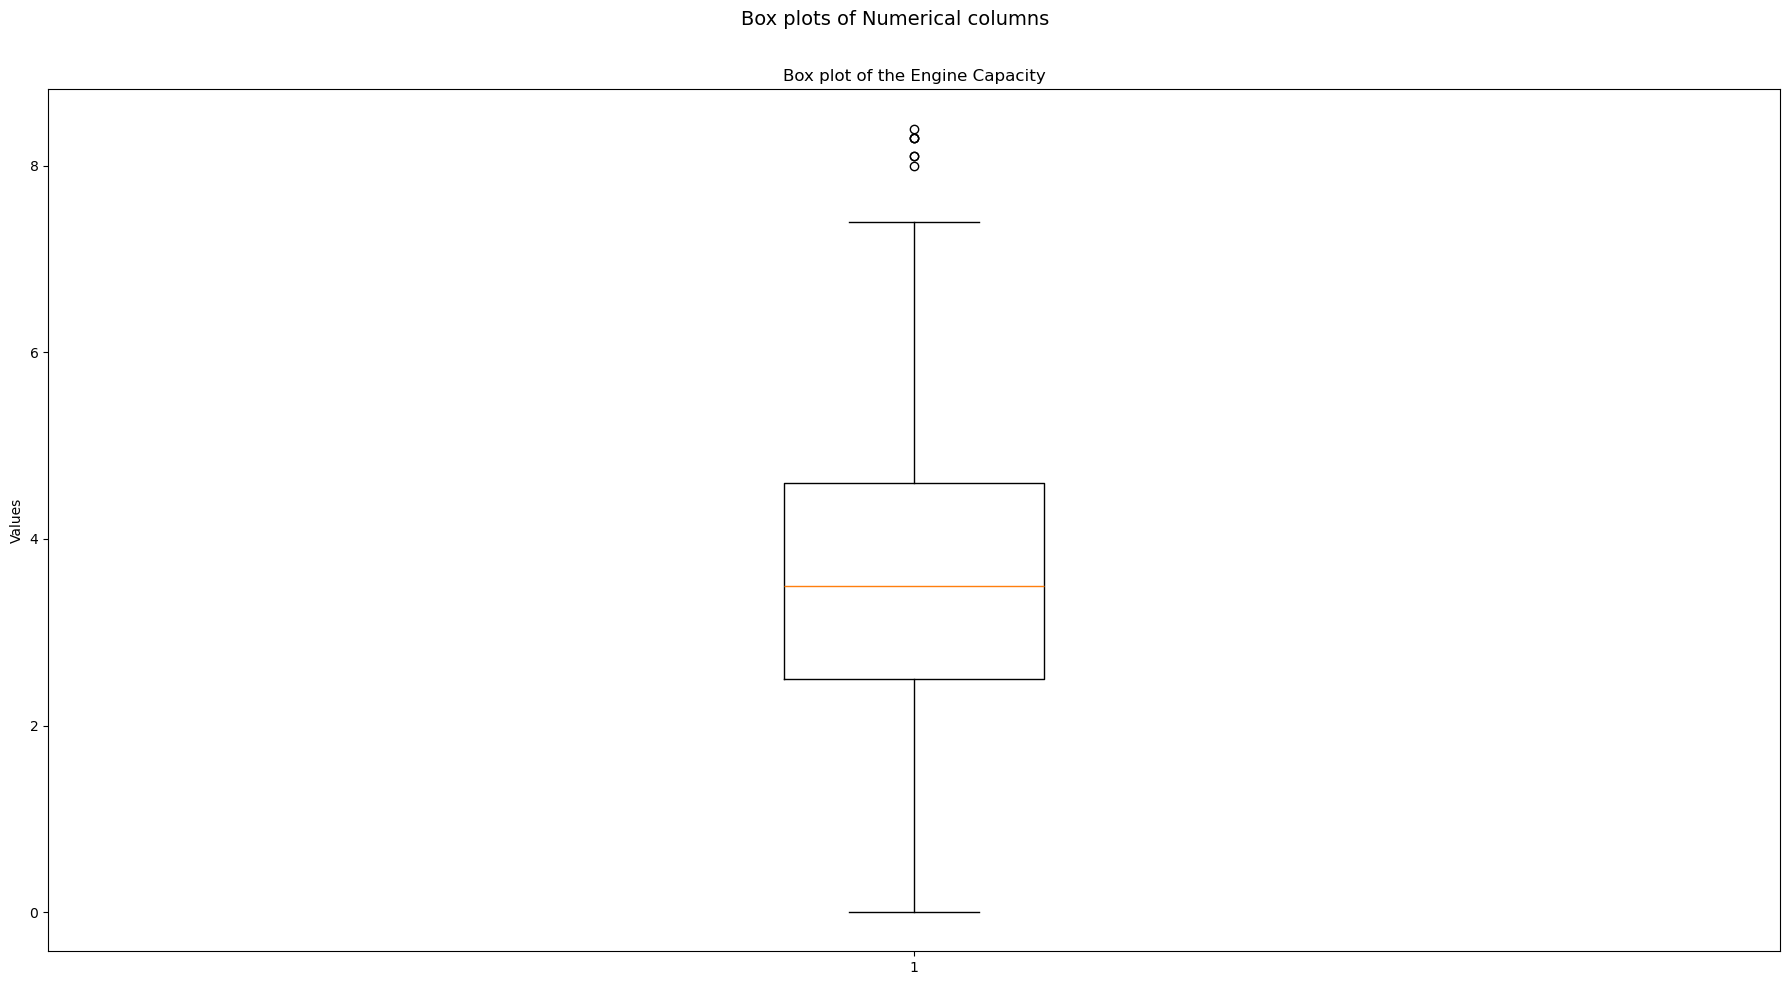

In [48]:
fig, axes=plt.subplots(figsize=(18,10))

axes.boxplot(df['Engine_Capacity'].dropna())
axes.set_title('Box plot of the Engine Capacity')
axes.set_ylabel('Values')
plt.suptitle("Box plots of Numerical columns", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [49]:
print(f"The missing percentage in the Engine_Capacity is: {round(df['Engine_Capacity'].isna().sum()/len(df)*100,2)}%")

The missing percentage in the Engine_Capacity is: 0.0%


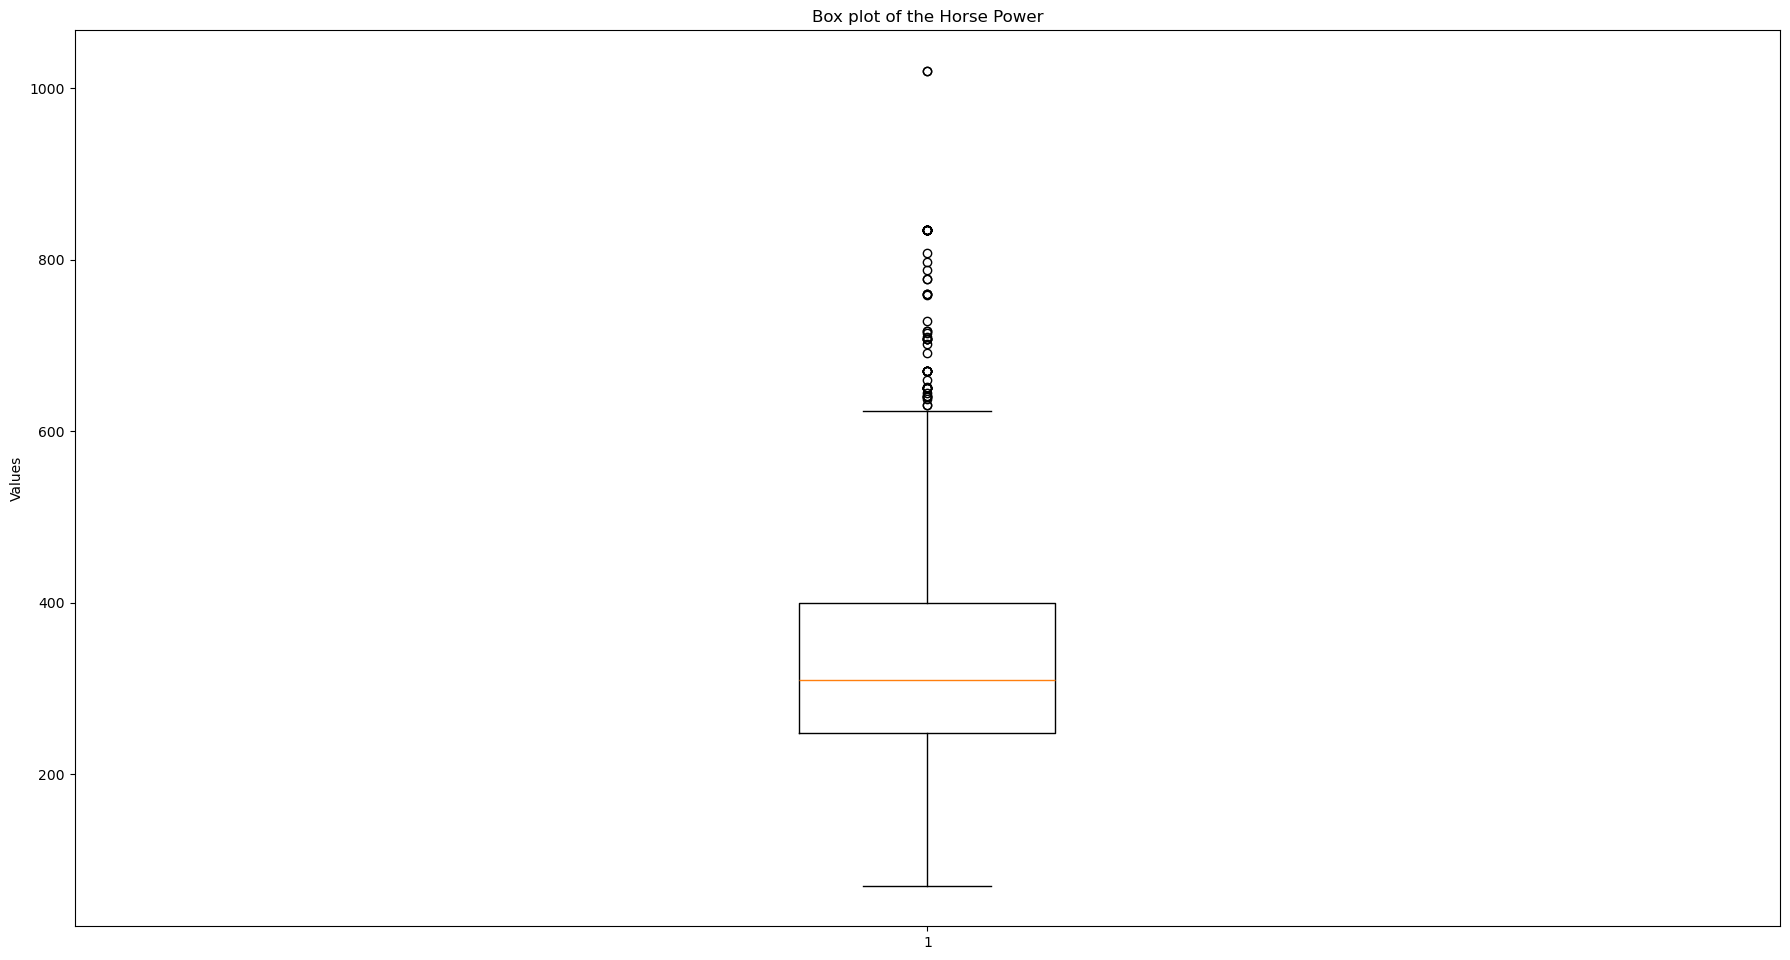

In [50]:
fig, axes=plt.subplots(figsize=(18,10))

axes.boxplot(df['Horse_Power'].dropna())
axes.set_title('Box plot of the Horse Power')
axes.set_ylabel('Values')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [51]:
skew_value=df['Horse_Power'].skew()
print(f'The skewness of Horse Power is: {skew_value: .3f}')

The skewness of Horse Power is:  0.947


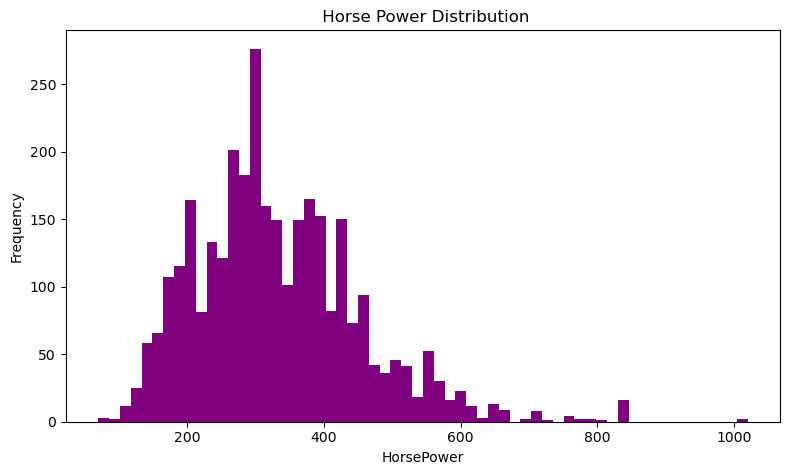

In [52]:
fig, axes=plt.subplots(figsize=(8,5))

axes.hist(df['Horse_Power'].dropna(),bins=60, color='purple')
axes.set_title(' Horse Power Distribution')
axes.set_xlabel('HorsePower')
axes.set_ylabel('Frequency')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

### Model based imputation
#### Use other features to predict Horse_Power using Linear Regression

Since Horse_Power has many missing values, instead of filling with mean (which destroys relationships), the code:

Engine + year + mileage + price + brand → predict horsepower

So we are saying:

"Cars with similar specs should have similar horsepower."

In [53]:
#Convert columns to numeric bcz regression only works w numbers
numeric_cols=['Engine_Capacity','model_year', 'milage', 'Horse_Power', 'price']
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric, errors='coerce')

#Split known vs missing horsepower
known=df[df['Horse_Power'].notna()]
missing=df[df['Horse_Power'].isna()]

#Define features
#These are input variables used to predict horsepower. Inputs (X): Engine_Capacity, milage, price, brand  Target (Y):Horse_Power
numerical_features=['Engine_Capacity','model_year', 'milage', 'price']
categorical_features=['brand']

#Create preprocessing pipeline  
preprocessor=ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

#Build ML pipeline   
#Pipeline means:Step 1 → preprocess data Step 2 → train regression
pipeline=Pipeline(steps=[
    ('preprocessors', preprocessor),
    ('regression', LinearRegression())

])

#Train the model
#Model learns: X → features   Y → horsepower
pipeline.fit(
    known[categorical_features+numerical_features],
    known['Horse_Power']
)

#Predict missing horsepower
predicted_horsepower= pipeline.predict(missing[categorical_features+numerical_features])

#Fill missing values
df.loc[df['Horse_Power'].isna(), 'Horse_Power']= predicted_horsepower

#Remove negative predictions
df['Horse_Power']=df['Horse_Power'].clip(lower=0)

print('All missing values are filled with linear regression imputation technique')

All missing values are filled with linear regression imputation technique


In [54]:
missing_info={}
for col in Numerical_Columns:
    if df[col].isnull().sum()>0:
        missing_count= df[col].isnull().sum()/len(df)*100
        missing_info[col]=round(missing_count, 2)

print("\nThe missing Numerical columns with perentage:\n")
for col,perc in missing_info.items():
    print(f'{col} : {perc}%')


The missing Numerical columns with perentage:



### Handling missing values of categorical columns

In [55]:
missing_info={}
for col in Categorical_Columns:
    if df[col].isnull().sum()>0:
        missing_count= df[col].isnull().sum()/len(df)*100
        missing_info[col]=round(missing_count, 2)

print("\nThe missing Categorical columns with perentage:\n")
for col,perc in missing_info.items():
    print(f'{col} : {perc}%')


The missing Categorical columns with perentage:

fuel_type : 4.24%


In [56]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.loc[df['fuel_type'].isna(), ['fuel_type', 'engine', 'transmission']]

,fuel_type,engine,transmission
9,NaN,534.0HP Electric Motor Electric Fuel System,A/T
44,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
68,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
92,NaN,835.0HP Electric Motor Electric Fuel System,1-Speed A/T
122,NaN,835.0HP Electric Motor Electric Fuel System,A/T
129,NaN,620.0HP Electric Motor Electric Fuel System,A/T
155,NaN,455.0HP Electric Motor Electric Fuel System,A/T
189,NaN,455.0HP Electric Motor Electric Fuel System,1-Speed A/T
225,NaN,670.0HP Electric Motor Electric Fuel System,A/T
236,NaN,Electric,1-Speed Automatic


In [57]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')

In [58]:
df['fuel_type']=df['fuel_type'].fillna('Electric')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,385.960419
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,54598.0,NO,3.5,392.181679
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,NO,2.0,334.169077


In [59]:
df.isnull().sum()

brand               0
model               0
model_year          0
milage              0
fuel_type           0
engine              0
transmission        0
ext_col             0
int_col             0
clean_title         0
price               0
Accident_Occured    0
Engine_Capacity     0
Horse_Power         0
dtype: int64

In [60]:
#engine w v6
v6_cars = df[df['engine'].str.contains('V6', case=False, na=False)]
v6_cars

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,385.960419
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,41927.0,NO,3.5,311.000000
10,Land,Rover Range Rover Sport 3.0 Supercharged HST,2021,27608.0,Gasoline,V6,Automatic,Fuji White,Pimento / Ebony,unknown,73897.0,NO,3.5,392.716051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3990,Ford,F-150 Lariat,2018,65441.0,Gasoline,325.0HP 2.7L V6 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,Yes,38000.0,NO,2.7,325.000000
3997,Chevrolet,Impala 2LZ,2018,71312.0,Gasoline,305.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,17899.0,NO,3.6,305.000000
4001,Volkswagen,Routan SE,2011,194000.0,Gasoline,283.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Gray,Yes,3500.0,YES,3.6,283.000000
4005,Audi,S4 3.0T Premium Plus,2022,10900.0,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,Yes,53900.0,NO,3.0,349.000000


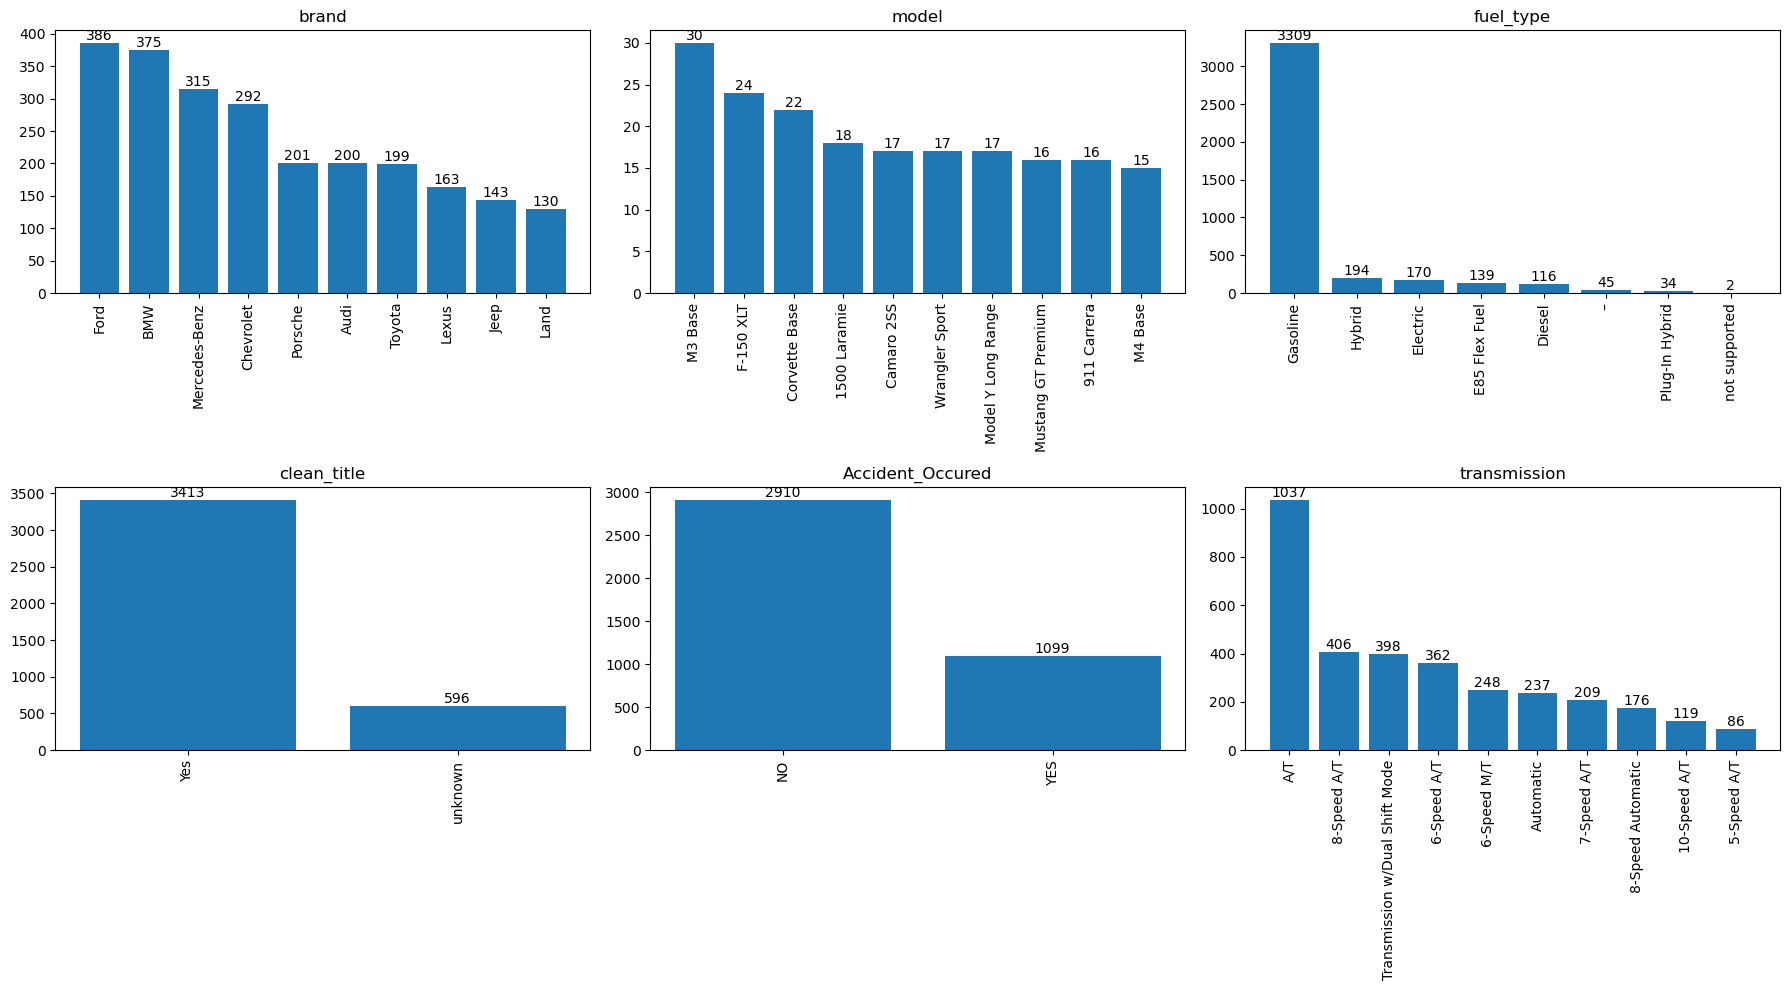

In [61]:
#bar graphs showing the most frequent category
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

cols = ['brand','model','fuel_type','clean_title','Accident_Occured','transmission']

for i, col in enumerate(cols):
    
    plt.subplot(2,3,i+1)
    
    counts = df[col].value_counts().reset_index().head(10)
    counts.columns = [col,'count']
    
    bars = plt.bar(counts[col], counts['count'])
    
    plt.title(col)
    plt.xticks(rotation=90)
    
    # add numbers on top of bars
    for bar in bars:
        height = bar.get_height()
        
        plt.text(
            bar.get_x()+bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight=400
        )

plt.tight_layout()
plt.show()

In [62]:
df.loc[df['fuel_type']=='–', ['brand','model', 'fuel_type','transmission', 'Engine_Capacity', 'Horse_Power']]

,brand,model,fuel_type,transmission,Engine_Capacity,Horse_Power
130,Chrysler,Pacifica Touring,–,9-Speed A/T,3.5,321.501593
257,Toyota,Land Cruiser Base,–,A/T,3.5,147.071251
338,Mazda,Mazda3 s Grand Touring,–,A/T,3.5,320.846223
491,Chrysler,Pacifica Touring,–,9-Speed A/T,3.5,337.436653
692,Honda,Civic EX,–,A/T,3.5,226.404721
855,Ford,Bronco,–,–,3.5,204.297014
923,Dodge,Challenger R/T,–,Transmission w/Dual Shift Mode,3.5,286.912554
995,Dodge,Challenger R/T Scat Pack,–,6-Speed M/T,3.5,367.687176
1063,Mazda,Mazda6 i Grand Touring,–,A/T,3.5,321.544451
1083,Dodge,Challenger R/T,–,A/T,3.5,300.551047


In [63]:
df.sort_values(by=['fuel_type'])

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
1075,Ford,F-250 XLT,2010,52246.0,Diesel,6.4L V8 32V DDI OHV Twin Turbo Diesel,6-Speed Manual,Tan,Medium Stone,Yes,26095.0,NO,6.4,415.774488
1059,Chevrolet,Silverado 3500 High Country,2015,77500.0,Diesel,397.0HP 6.6L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,Black,Brown,Yes,54000.0,NO,6.6,397.000000
1848,Mercedes-Benz,Sprinter 3500 High Roof,2022,105.0,Diesel,161.0HP 2.0L 4 Cylinder Engine Diesel Fuel,7-Speed A/T,Black,Orange,Yes,200000.0,NO,2.0,161.000000
3456,Ford,F-250 King Ranch,2020,36500.0,Diesel,475.0HP 6.7L 8 Cylinder Engine Diesel Fuel,10-Speed A/T,Gray,Brown,Yes,69900.0,NO,6.7,475.000000
1358,RAM,2500 Tradesman,2018,52000.0,Diesel,350.0HP 6.7L Straight 6 Cylinder Engine Diesel...,6-Speed A/T,Gray,Black,Yes,50000.0,NO,6.7,350.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3918,Porsche,911 Carrera Cabriolet,1996,38000.0,–,–,Transmission w/Dual Shift Mode,Blue,Gray,unknown,75000.0,YES,3.5,274.442235
1746,Nissan,300ZX Base,1993,168000.0,–,–,5-Speed M/T,White,Black,Yes,7000.0,NO,3.5,171.677150
2115,Dodge,Challenger SRT 392,2016,37700.0,–,–,8-Speed A/T,Black,Black,Yes,38000.0,YES,3.5,352.499900
923,Dodge,Challenger R/T,2010,100100.0,–,–,Transmission w/Dual Shift Mode,Purple,Black,Yes,17000.0,NO,3.5,286.912554


#### Most Dodge cars use gasoline → safe imputation (Rule based imputation)

df.loc[ CONDITION , COLUMN ] = VALUE

In [64]:
df.loc[(df['brand'].str.lower()== 'dodge') & (df['fuel_type']== '–'), 'fuel_type'] ='Gasoline'

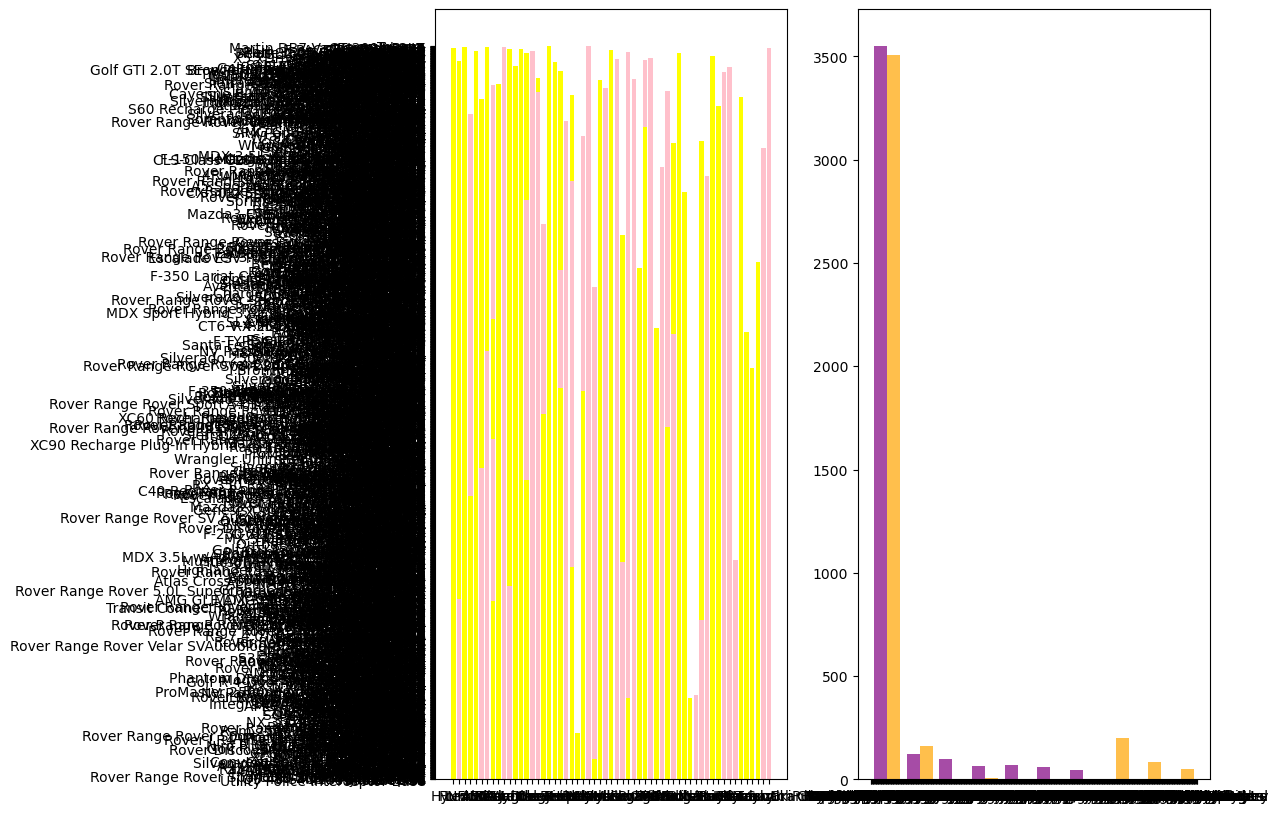

In [65]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.bar(df['brand'], df['model'], color=['pink','yellow'])

plt.subplot(1,2,2)
plt.hist([df['ext_col'],df['int_col']], bins=10, color=['purple','orange'], alpha=0.7)
plt.show()


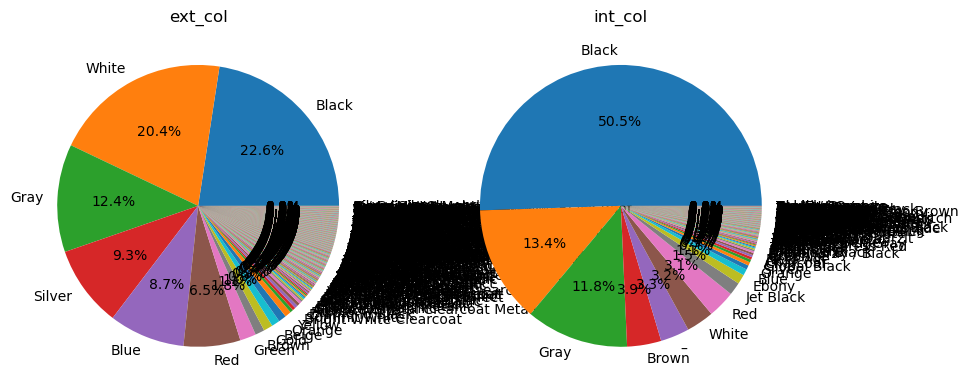

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(10,5))

cols = ['ext_col','int_col']

for i, col in enumerate(cols):
    counts = df[col].value_counts()
    
    axes[i].pie(counts,
                labels=counts.index,
                autopct='%1.1f%%')
    
    axes[i].set_title(col)

plt.show()

In [67]:
same_color_cars = df[df['ext_col'] == df['int_col']]
same_color_cars

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,Yes,7300.0,NO,4.4,282.000000
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,41927.0,NO,3.5,311.000000
9,Tesla,Model X Long Range Plus,2020,34000.0,Electric,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,Yes,69950.0,NO,0.0,534.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3998,Porsche,911 Carrera,2015,43500.0,Gasoline,350.0HP 3.4L Flat 6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,Yes,66500.0,NO,3.4,350.000000
4000,Subaru,Ascent Touring 7-Passenger,2021,32250.0,Gasoline,260.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,Yes,36000.0,YES,2.4,260.000000
4003,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705.0,Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,Yes,25900.0,YES,2.0,241.000000
4005,Audi,S4 3.0T Premium Plus,2022,10900.0,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,Yes,53900.0,NO,3.0,349.000000


### Outliers Detection for Numerical Columns

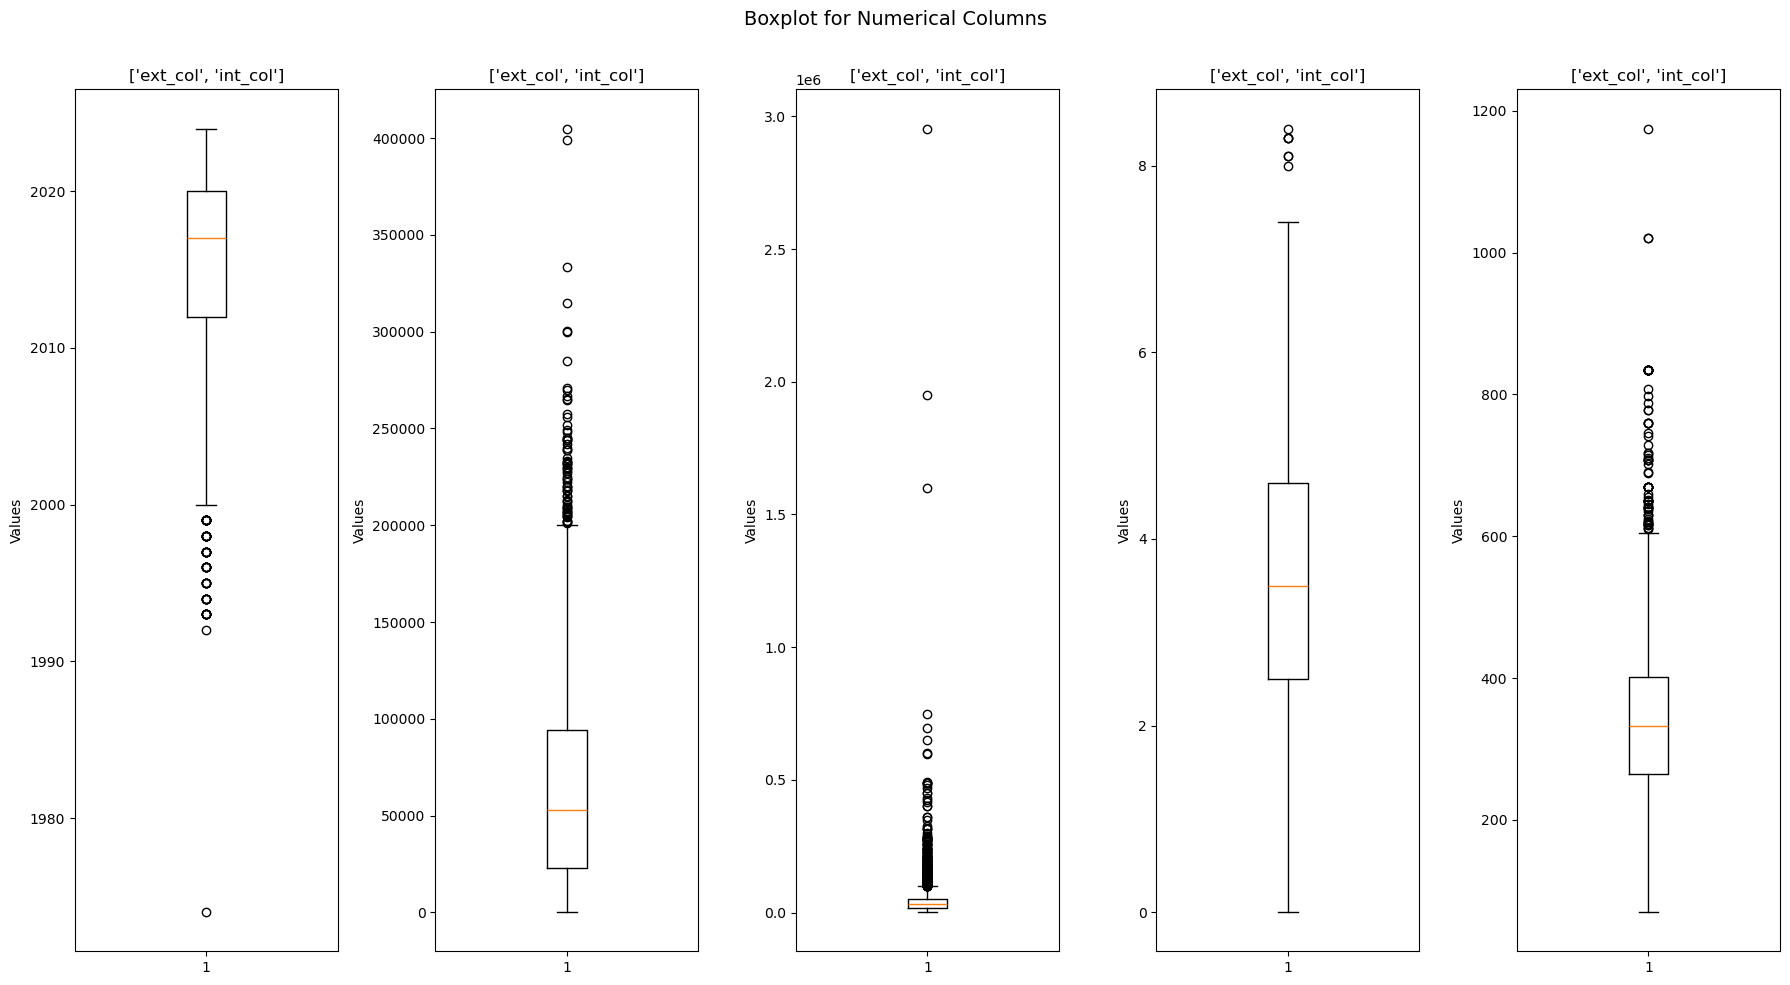

In [68]:
fig, axes= plt.subplots(1, len(Numerical_Columns), figsize=(18,10))

for i, col in enumerate(Numerical_Columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(cols)
    axes[i].set_ylabel("Values")
plt.suptitle("Boxplot for Numerical Columns", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

#### Histogram w kde and Q-Q plots

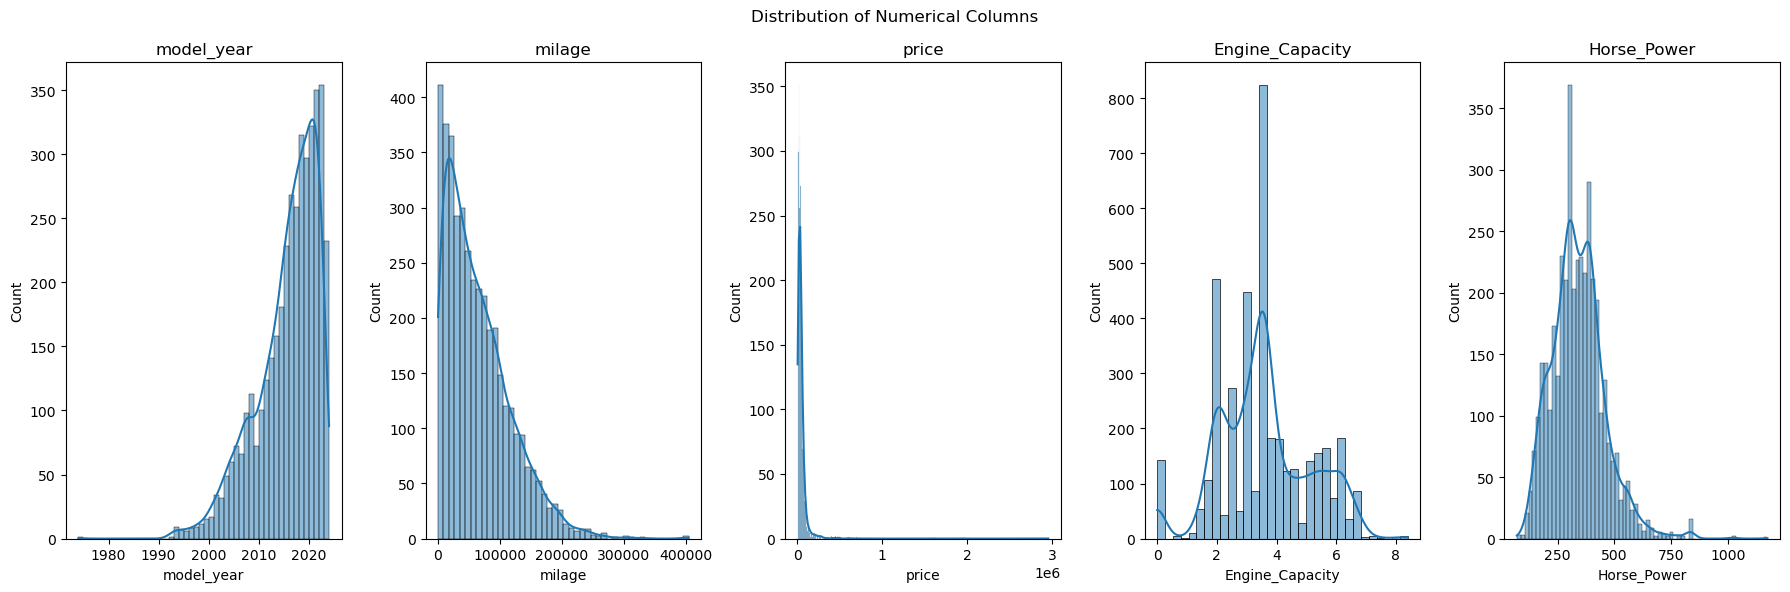

In [69]:
import seaborn as sns

fig, axes= plt.subplots(1,len(Numerical_Columns), figsize=(18,6))

for i,col in enumerate(Numerical_Columns):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribution of Numerical Columns")

plt.tight_layout()

plt.show()

#### Procdedure to remove outliers frm the numerical column

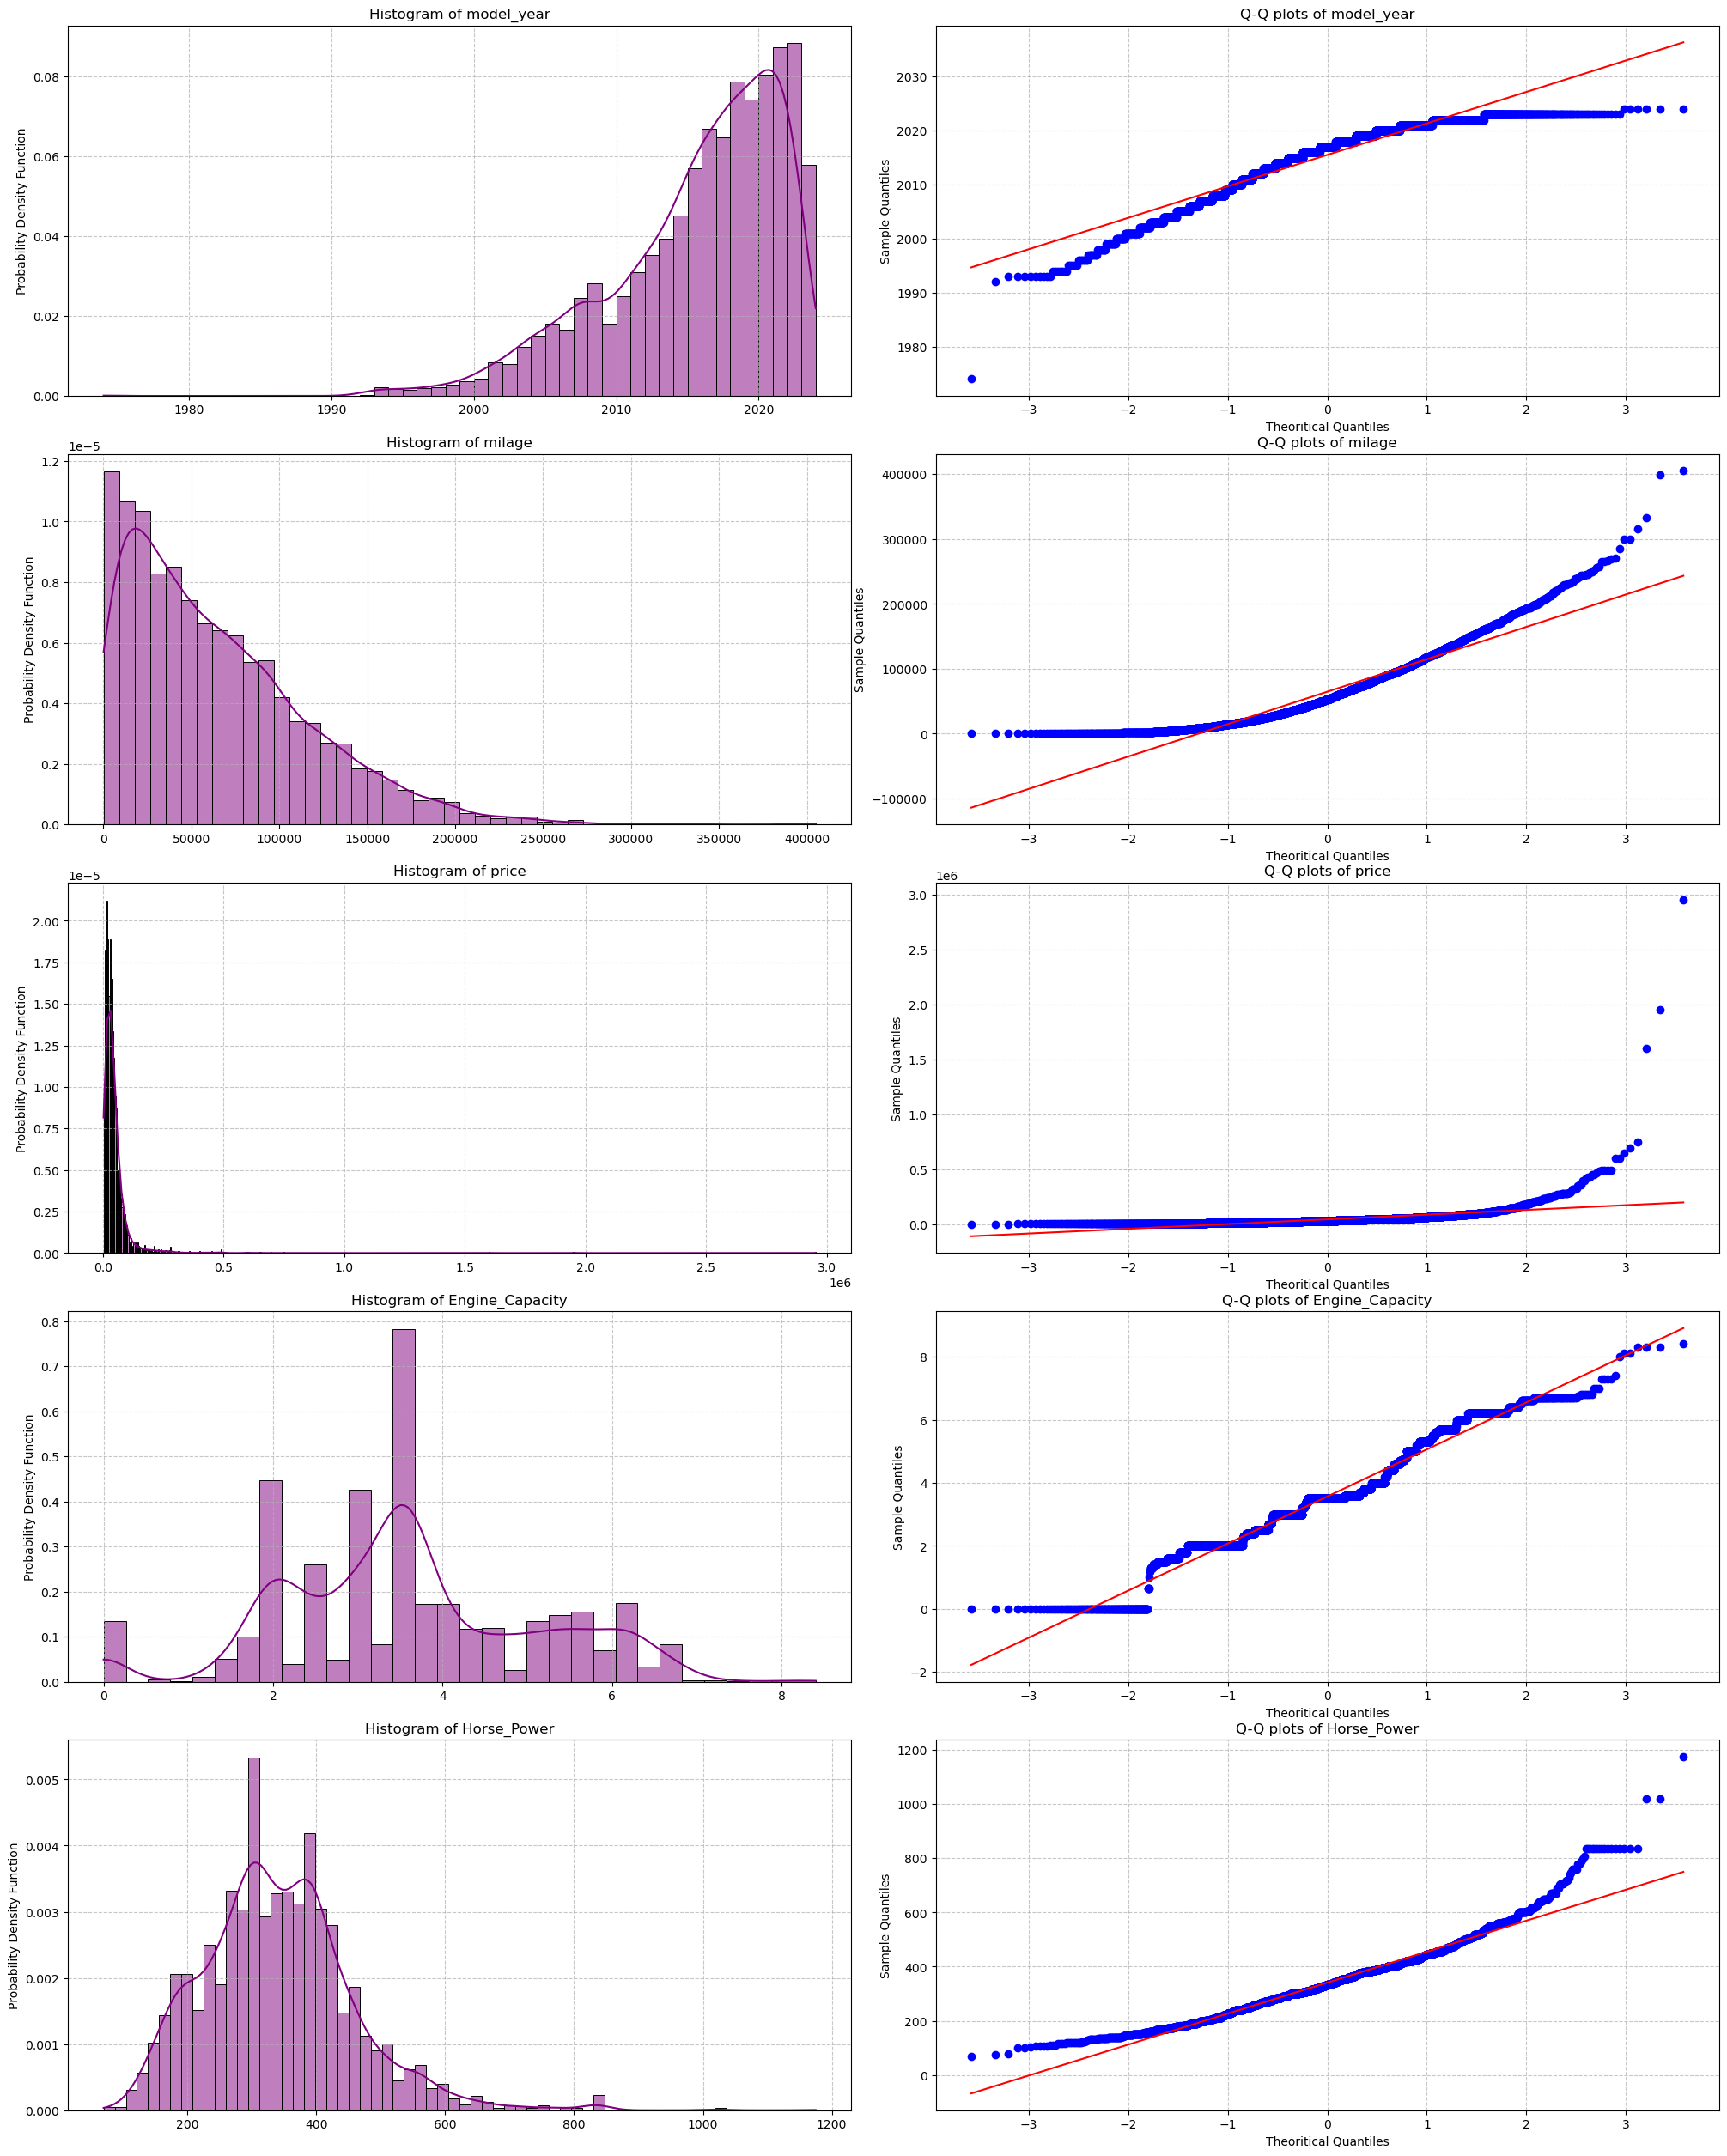

In [70]:
import scipy.stats as stats
num_cols=len(Numerical_Columns)
fig, axes= plt.subplots(num_cols, 2, figsize=(20, num_cols*5))

for i,cols in enumerate(Numerical_Columns):
    sns.histplot(df[cols].dropna(), kde=True, color='purple', ax=axes[i,0], stat='density',linewidth=0.7)
    axes[i,0].set_title(f"Histogram of {cols}")
    axes[i,0].set_xlabel("")
    axes[i,0].set_ylabel(f"Probability Density Function")
    axes[i,0].grid(True, linestyle='--', alpha=0.7)

    stats.probplot(df[cols], plot=axes[i,1], dist='norm', fit=True)
    axes[i,1].set_title(f"Q-Q plots of {cols}")
    axes[i,1].set_xlabel("Theoritical Quantiles")
    axes[i,1].set_ylabel(f"Sample Quantiles")
    axes[i,1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(pad=0.3)
plt.show()





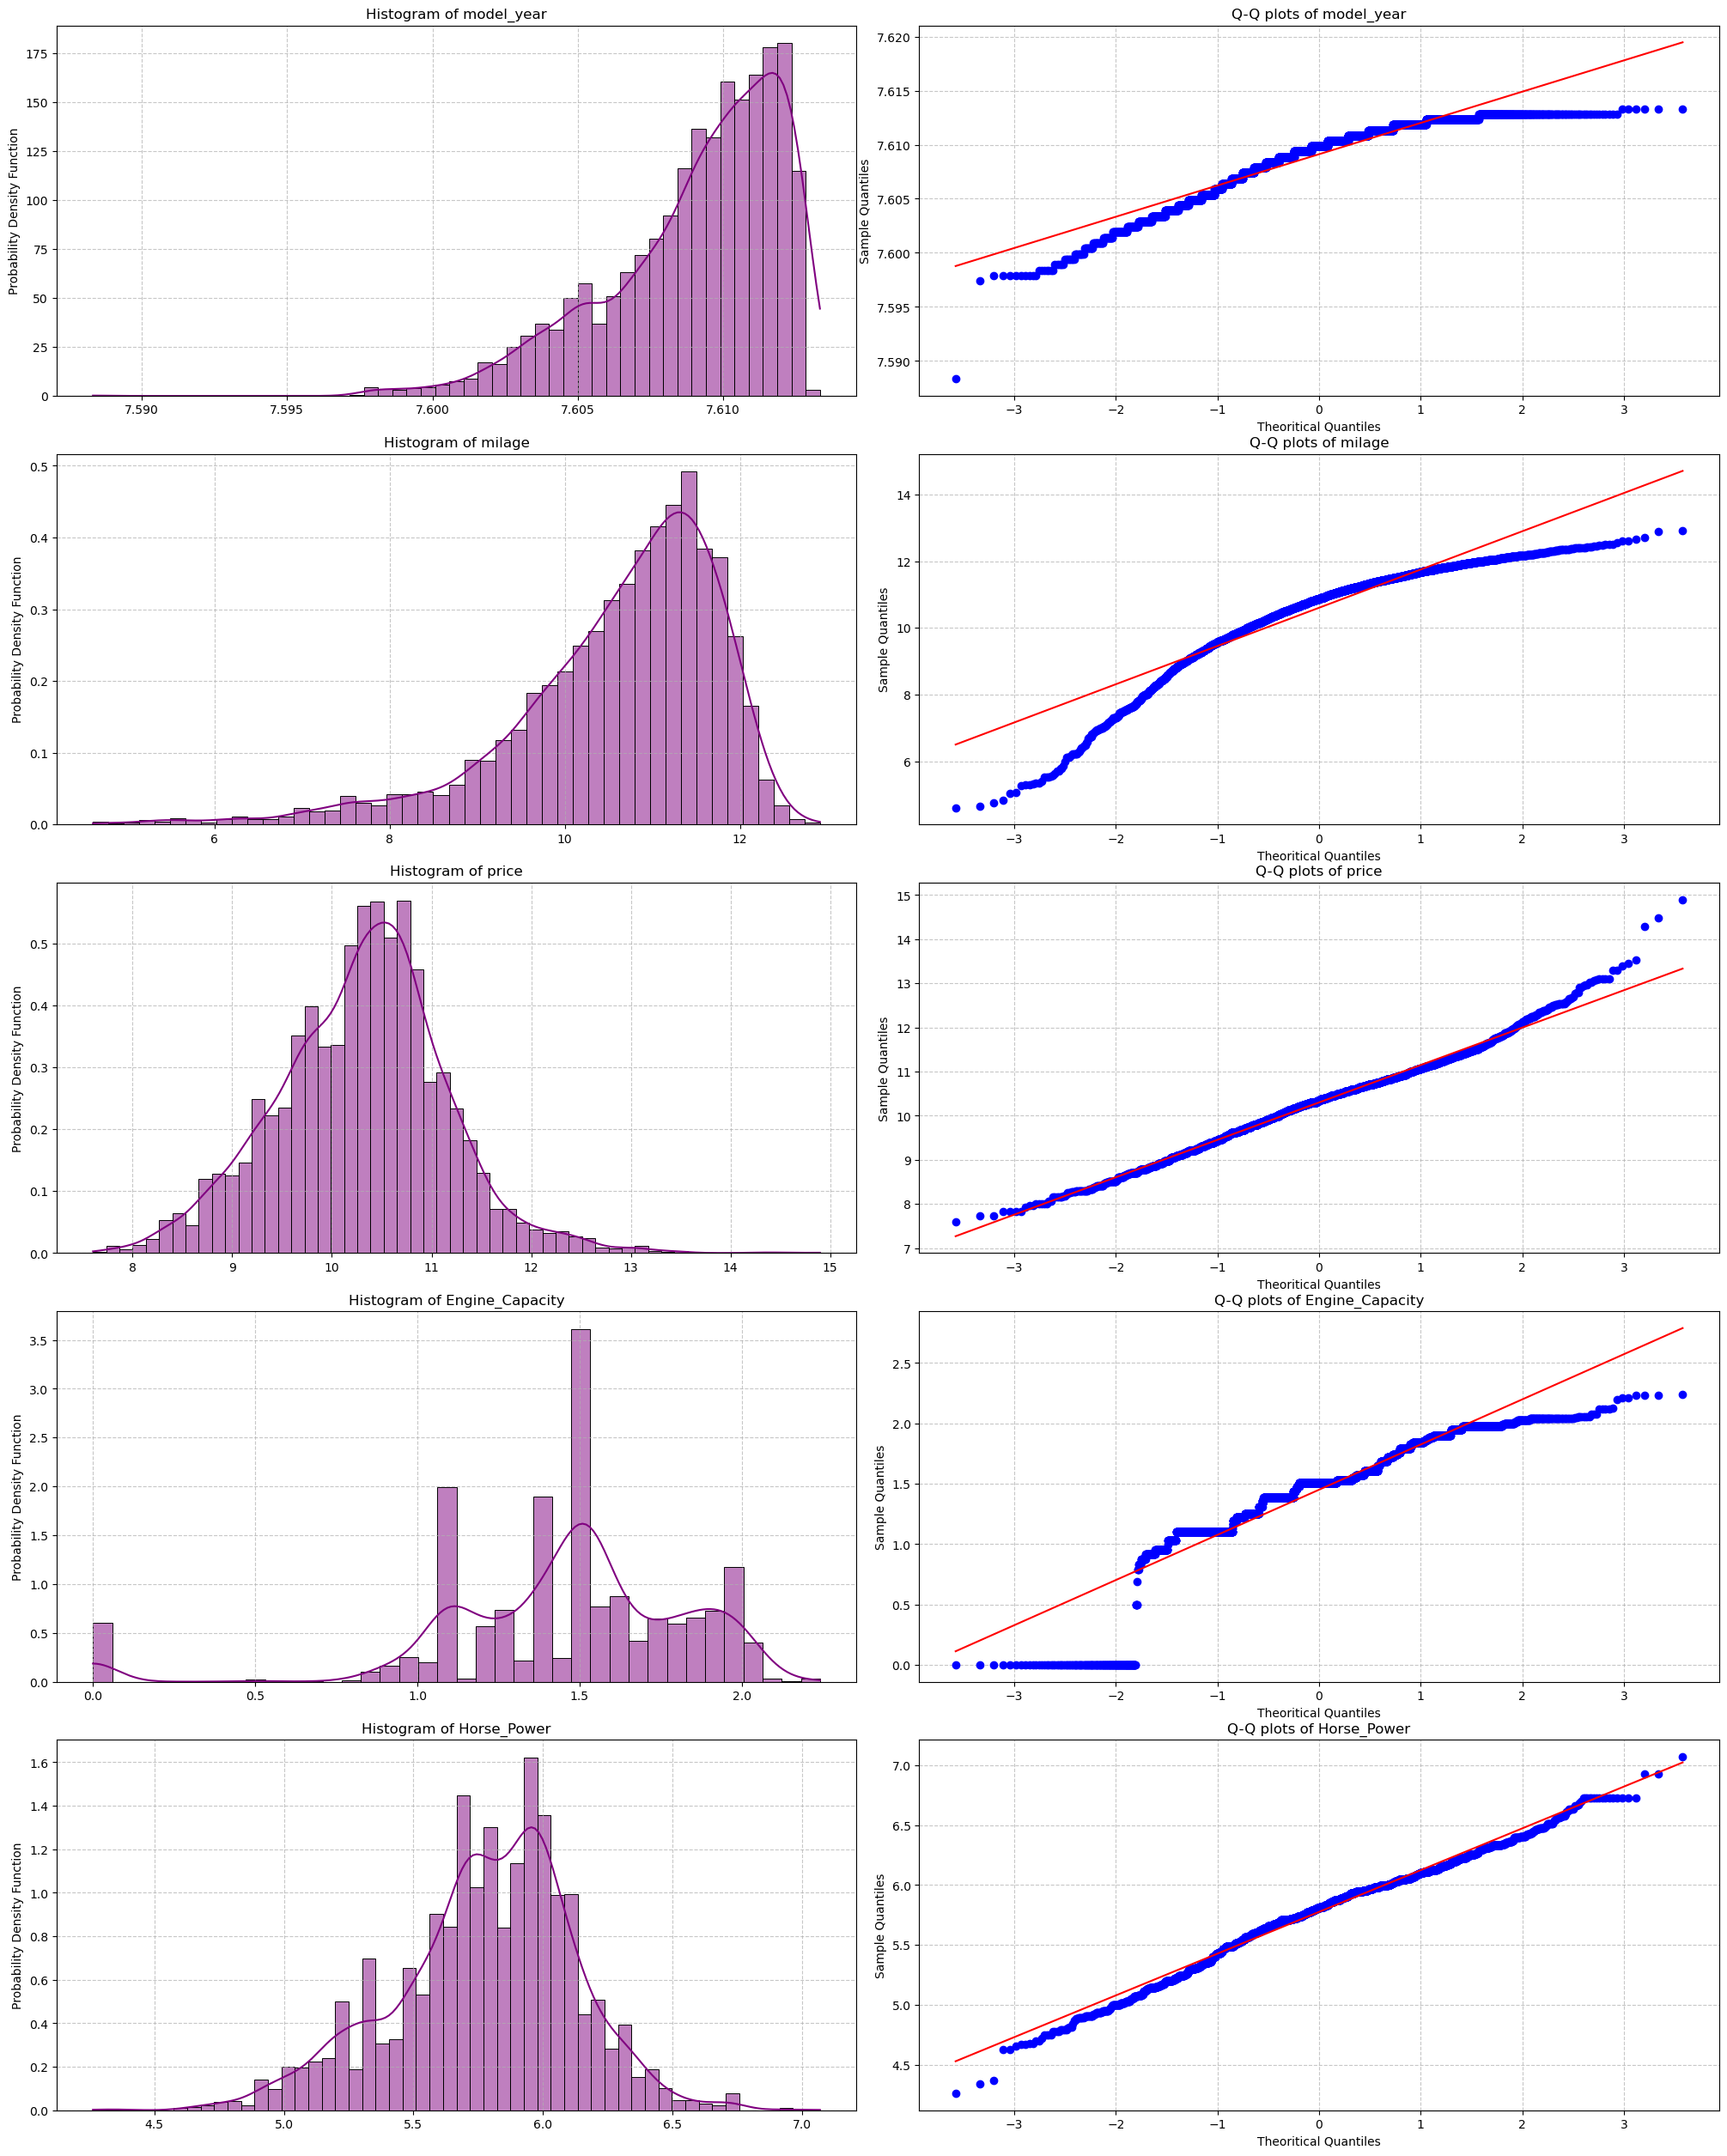

In [71]:
#transform data into log and exp then plot hist and qq
num_cols=len(Numerical_Columns)
fig, axes= plt.subplots(num_cols, 2, figsize=(20, num_cols*5))

for i,cols in enumerate(Numerical_Columns):
    log_data=np.log1p(df[cols].dropna())
    sns.histplot(log_data, kde=True, color='purple', ax=axes[i,0], stat='density',linewidth=0.7)
    axes[i,0].set_title(f"Histogram of {cols}")
    axes[i,0].set_xlabel("")
    axes[i,0].set_ylabel(f"Probability Density Function")
    axes[i,0].grid(True, linestyle='--', alpha=0.7)


    stats.probplot(log_data, plot=axes[i,1], dist='norm', fit=True)
    axes[i,1].set_title(f"Q-Q plots of {cols}")
    axes[i,1].set_xlabel("Theoritical Quantiles")
    axes[i,1].set_ylabel(f"Sample Quantiles")
    axes[i,1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(pad=0.3)
plt.show()





### Pair Plot

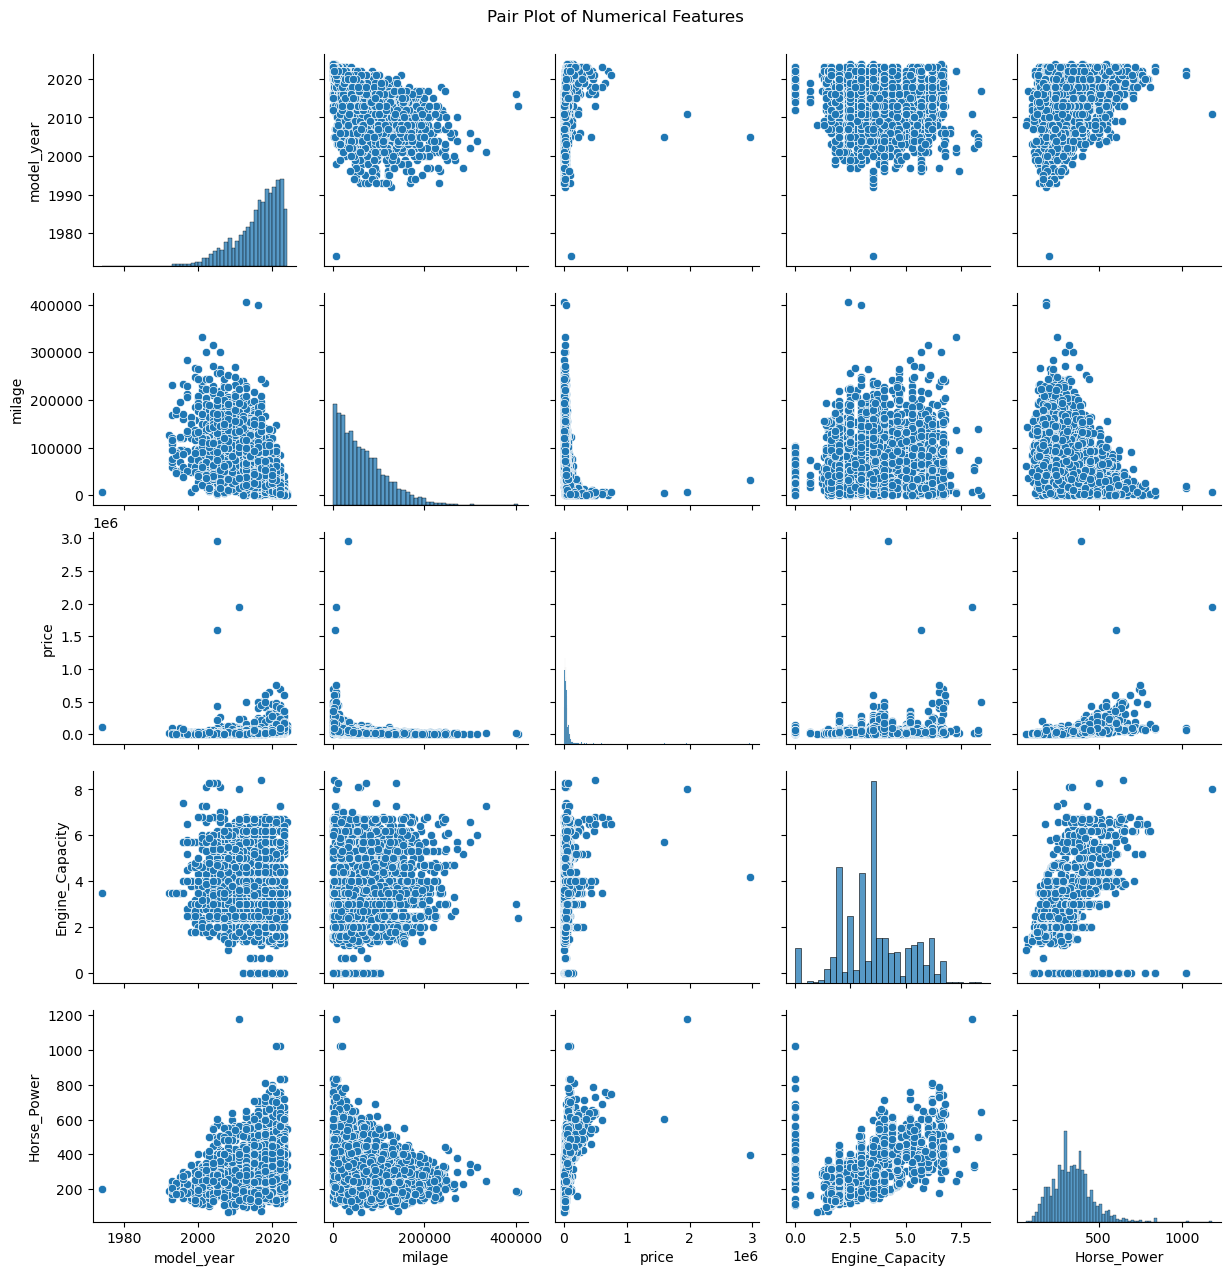

In [72]:
sns.pairplot(df[Numerical_Columns].dropna())

plt.suptitle("Pair Plot of Numerical Features", y=1.02)

plt.show()

### Polar Plot

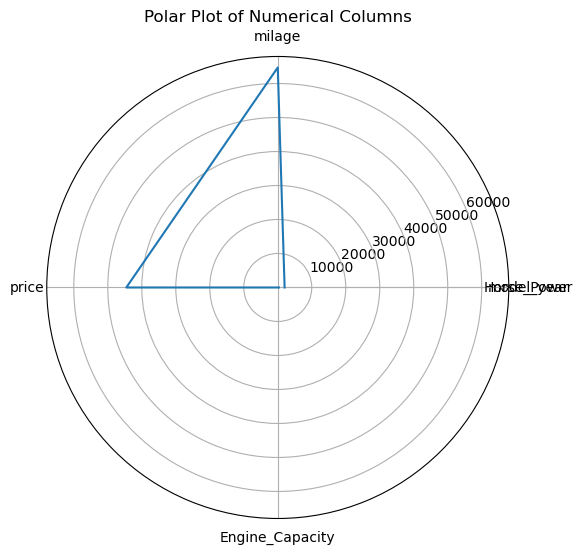

In [73]:
means = df[Numerical_Columns].mean()

theta = np.linspace(0, 2*np.pi, len(means))

fig = plt.figure(figsize=(6,6))

ax = fig.add_subplot(111, projection='polar')

ax.plot(theta, means)

ax.set_xticks(theta)

ax.set_xticklabels(Numerical_Columns)

ax.set_title("Polar Plot of Numerical Columns")

plt.show()

### Radar Chart

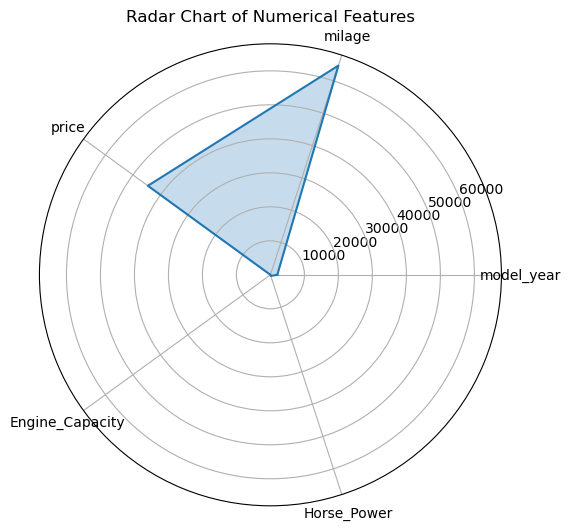

In [74]:
values = df[Numerical_Columns].mean().values

labels = Numerical_Columns

angles = np.linspace(0,2*np.pi,len(labels),endpoint=False)

# close shape
values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(6,6))

ax = plt.subplot(111, polar=True)

ax.plot(angles, values)

ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels)

ax.set_title("Radar Chart of Numerical Features")

plt.show()

### Strong Evidence to Statistical Test
#### To choose whether the data is normal or not


In [75]:
def testing_normality(df, col):
    print('-'*70)
    print(f'Normality Tests for Columns:*{col}*')
    print ('-'*70)

    # Shapiro
    stat, p=shapiro(df[col])
    print(f"shapiro-wilk test:stat={stat:.4f}, p={p:.4f} -> {'Normal' if p>0.05 else 'Not Normal'}")
     
    # Anderson 
    value= anderson(df[col])
    critical_value=value.critical_values[2]
    print(f"Anderson Darlings Test: stat={value.statistic: .4f}, critical_value={critical_value: .4f} -> {'Normal' if value.statistic<critical_value else 'Not Normal'}")

    # Jarque Bera
    jb_stats, jb_p=jarque_bera(df[col])
    print(f"Jarque Bera Test: stat={jb_stats:.4f}, p={jb_p:.4f} -> {'Normal' if jb_p>0.05 else 'Not Normal'}")

    # KS test (must standardize)
    standardized = (df[col]-np.mean(df[col]))/np.std(df[col])
    stat, p = kstest(standardized,'norm')
    print(f"KS test: stat={stat:.4f}, p={p:.4f} -> {'Normal' if p>0.05 else 'Not Normal'}")


    # Lilliefors
    lillie_stat, lillie_p = lilliefors(df[col])
    print(f"Lilliefors: stat={lillie_stat:.4f}, p={lillie_p:.4f} -> {'Normal' if lillie_p>0.05 else 'Not Normal'}")

    # D'Agostino Pearson
    stat, p = normaltest(df[col])
    print(f"D'Agostino-Pearson: stat={stat:.4f}, p={p:.4f} -> {'Normal' if p>0.05 else 'Not Normal'}")

for col in Numerical_Columns:
    testing_normality(df, col)


----------------------------------------------------------------------
Normality Tests for Columns:*model_year*
----------------------------------------------------------------------
shapiro-wilk test:stat=0.9090, p=0.0000 -> Not Normal
Anderson Darlings Test: stat= 102.2070, critical_value= 0.7860 -> Not Normal
Jarque Bera Test: stat=993.7930, p=0.0000 -> Not Normal
KS test: stat=0.1295, p=0.0000 -> Not Normal
Lilliefors: stat=0.1295, p=0.0010 -> Not Normal
D'Agostino-Pearson: stat=630.5740, p=0.0000 -> Not Normal
----------------------------------------------------------------------
Normality Tests for Columns:*milage*
----------------------------------------------------------------------
shapiro-wilk test:stat=0.9105, p=0.0000 -> Not Normal
Anderson Darlings Test: stat= 85.9013, critical_value= 0.7860 -> Not Normal
Jarque Bera Test: stat=1407.6247, p=0.0000 -> Not Normal
KS test: stat=0.1083, p=0.0000 -> Not Normal
Lilliefors: stat=0.1083, p=0.0010 -> Not Normal
D'Agostino-Pearson: 

In [76]:
testing_normality(df,'Horse_Power')

----------------------------------------------------------------------
Normality Tests for Columns:*Horse_Power*
----------------------------------------------------------------------
shapiro-wilk test:stat=0.9624, p=0.0000 -> Not Normal
Anderson Darlings Test: stat= 17.0439, critical_value= 0.7860 -> Not Normal
Jarque Bera Test: stat=1439.9787, p=0.0000 -> Not Normal
KS test: stat=0.0519, p=0.0000 -> Not Normal
Lilliefors: stat=0.0519, p=0.0010 -> Not Normal
D'Agostino-Pearson: stat=611.9554, p=0.0000 -> Not Normal


##### Function to detect outliers using IQR Method


In [77]:
def detect_outliers_using_iqr(data):
    outlier_mask=pd.Series(index=data.columns, dtype=bool)

    for col in data.columns:
        if col in Numerical_Columns:
            Q1=data[col].quantile(0.25)
            Q3=data[col].quantile(0.75)
            IQR= Q3-Q1
            lower_bound=Q1-1.5*IQR
            upper_bound=Q3+1.5*IQR
            col_outliers_mask=(
                (data[col]<lower_bound) | (data[col]>upper_bound)
            )
            outlier_mask[col]=col_outliers_mask.any()
    return outlier_mask

outliers_iqr_mask=detect_outliers_using_iqr(df)
print("\nOutliers detected using IQR is :\n")
for col, is_outlier in outliers_iqr_mask.items():
    print(f'{col}: {is_outlier}')


Outliers detected using IQR is :

brand: True
model: True
model_year: True
milage: True
fuel_type: True
engine: True
transmission: True
ext_col: True
int_col: True
clean_title: True
price: True
Accident_Occured: True
Engine_Capacity: True
Horse_Power: True


##### Function to detect outliers using Z-Score Method

In [78]:
def detect_outliers_using_zscore(data, threshold=3):
    outlier_mask=pd.Series(index=data.columns, dtype=bool)

    for col in data.columns:
        if col in Numerical_Columns:
            mean= np.mean(data[col])
            std_deviation= np.std(data[col])
            z_scores= np.abs((data[col]-mean)/std_deviation)
            col_outliers_mask= z_scores>threshold
            outlier_mask[col]=col_outliers_mask.any()
    return outlier_mask

outliers_zscore_mask=detect_outliers_using_zscore(df)
print("\n Outliers detected using Z-Score is:\n")
for col, is_outlier in outliers_zscore_mask.items():
    print(f'{col}: {is_outlier}')


 Outliers detected using Z-Score is:

brand: True
model: True
model_year: True
milage: True
fuel_type: True
engine: True
transmission: True
ext_col: True
int_col: True
clean_title: True
price: True
Accident_Occured: True
Engine_Capacity: True
Horse_Power: True


##### Function to remove outliers using IQR Method


In [79]:
def remove_outliers_iqr(data, Numerical_Columns):
    cleaned_data=data.copy()

    for col in Numerical_Columns:
        Q1=cleaned_data[col].quantile(0.25)
        Q3=cleaned_data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        cleaned_data=cleaned_data[
            (cleaned_data[col]>=lower_bound) & (cleaned_data[col]<=upper_bound)
        ]
    return cleaned_data

cleaned_data_iqr= remove_outliers_iqr(df, Numerical_Columns)
print("Dataframe after removing Outliers using IQR method:")
print(cleaned_data_iqr)

Dataframe after removing Outliers using IQR method:
              brand                            model  model_year   milage  \
0              Ford  Utility Police Interceptor Base        2013  51000.0   
1           Hyundai                     Palisade SEL        2021  34742.0   
2             Lexus                    RX 350 RX 350        2022  22372.0   
3          INFINITI                 Q50 Hybrid Sport        2015  88900.0   
4              Audi        Q3 45 S line Premium Plus        2021   9835.0   
...             ...                              ...         ...      ...   
4003  Mercedes-Benz             E-Class E 300 4MATIC        2018  53705.0   
4005           Audi             S4 3.0T Premium Plus        2022  10900.0   
4006        Porsche                           Taycan        2022   2116.0   
4007           Ford                     F-150 Raptor        2020  33000.0   
4008            BMW                     X3 xDrive30i        2020  43000.0   

          fuel_type    

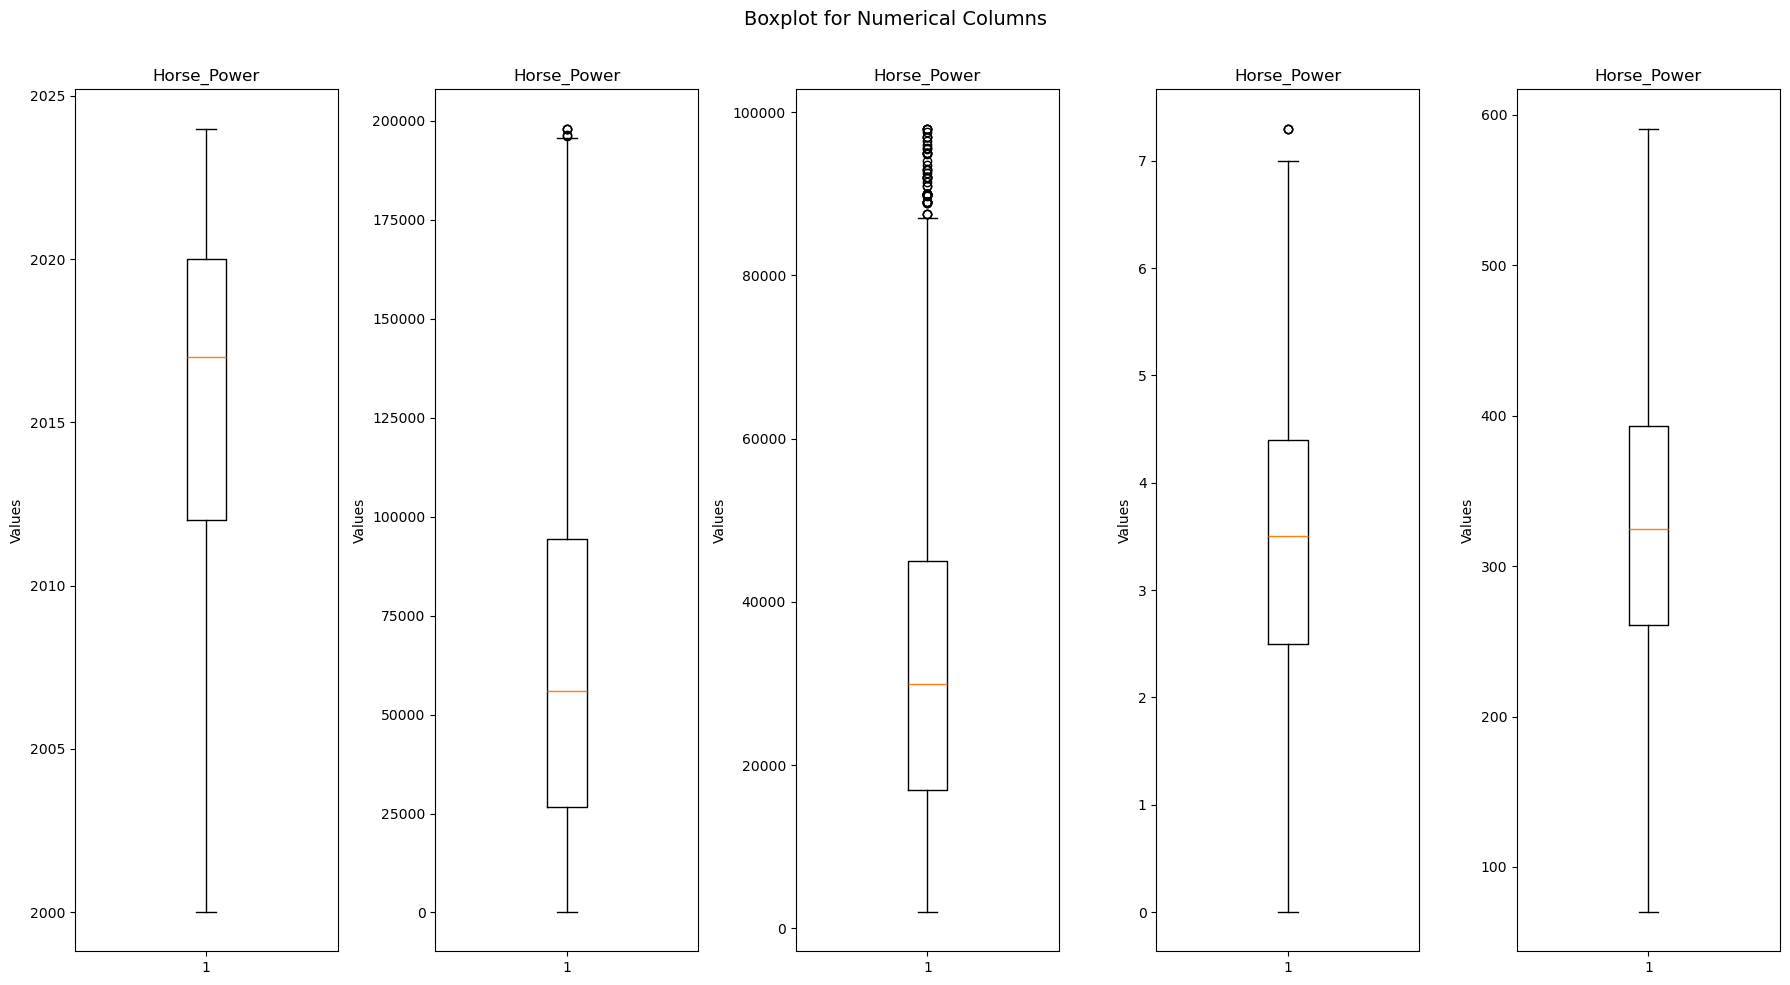

In [80]:
fig, axes= plt.subplots(1, len(Numerical_Columns), figsize=(18,10))

for i, col in enumerate(Numerical_Columns):
    axes[i].boxplot(cleaned_data_iqr[col].dropna())
    axes[i].set_title(cols)
    axes[i].set_ylabel("Values")
plt.suptitle("Boxplot for Numerical Columns", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

##### Function to remove outliers using Z-Score Method


In [81]:
def remove_outliers_zscore(data, Numerical_Columns, threshold=3):
    cleaned_data=data.copy()

    for col in Numerical_Columns:
        z_scores=zscore(cleaned_data[col])
        cleaned_data=cleaned_data[abs(z_scores)<=threshold]
    return cleaned_data

cleaned_data_z_score= remove_outliers_zscore(df, Numerical_Columns)
print("Dataframe after removing Outliers using Z-Score method:")
print(cleaned_data_z_score)

Dataframe after removing Outliers using Z-Score method:
              brand                            model  model_year   milage  \
0              Ford  Utility Police Interceptor Base        2013  51000.0   
1           Hyundai                     Palisade SEL        2021  34742.0   
2             Lexus                    RX 350 RX 350        2022  22372.0   
3          INFINITI                 Q50 Hybrid Sport        2015  88900.0   
4              Audi        Q3 45 S line Premium Plus        2021   9835.0   
...             ...                              ...         ...      ...   
4003  Mercedes-Benz             E-Class E 300 4MATIC        2018  53705.0   
4005           Audi             S4 3.0T Premium Plus        2022  10900.0   
4006        Porsche                           Taycan        2022   2116.0   
4007           Ford                     F-150 Raptor        2020  33000.0   
4008            BMW                     X3 xDrive30i        2020  43000.0   

          fuel_type

In [82]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,385.960419
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,54598.0,NO,3.5,392.181679
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,NO,2.0,334.169077


In [83]:
df.drop('engine', axis=1, inplace=True)

In [84]:
df.to_csv('../data/processed_data.csv', index=False)

### Machine Learning Implementations 

In [85]:
data=pd.read_csv('../data/processed_data.csv')

In [86]:
data.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,Accident_Occured,Engine_Capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,385.960419
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,Automatic,Blue,Black,unknown,54598.0,NO,3.5,392.181679
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,NO,2.0,334.169077


#### Data Preprocessing

In [87]:
Target_cols='price'
X=data.drop(columns=[Target_cols])
y=data[Target_cols]

low=y.quantile(0.01)
high=y.quantile(0.99)

mask=(y>=low) & (y<=high)
X=X[mask]
Y=y[mask]

X_train, X_test, y_train, y_test= train_test_split(X,Y, test_size=0.3, random_state=42)

In [88]:
num_cols=X_train.select_dtypes(include=np.number).columns.to_list()
cat_cols=X_train.select_dtypes(exclude=np.number).columns.to_list()

low_card_cols=[c for c in cat_cols if X_train[c].nunique()<=10]
mid_card_cols=[c for c in cat_cols if 10< X_train[c].nunique()<=50]
high_card_cols=[c for c in cat_cols if X_train[c].nunique()>10]

print('Low:', low_card_cols)
print('Mid:', mid_card_cols)
print('High:', high_card_cols)



Low: ['fuel_type', 'clean_title', 'Accident_Occured']
Mid: []
High: ['brand', 'model', 'transmission', 'ext_col', 'int_col']


In [89]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols=cols
        self.maps={}
    
    def fit(self, X, y=None):
        self.maps = {}   
        for col in self.cols:
            self.maps[col]=X[col].value_counts(normalize=True)
        return self
    
    def transform(self, X):
        X=X.copy()
        for col in self.cols:
            X[col]=X[col].map(self.maps[col]).fillna(0)
        return X 

In [90]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols+high_card_cols),
        ('loW_card', OneHotEncoder(handle_unknown='ignore'), low_card_cols),
        ('mid_card', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), mid_card_cols)

    ]
)


### Feature Selector

In [91]:
feature_selector=SelectFromModel(Lasso(alpha=0.001))

In [92]:
model=Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('feature_selector', feature_selector),
    ('regressor', TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1

    ))
])

In [93]:
model.fit(X_train, y_train)

Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_Occured']),
                                                 ('mid_card',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [])])),
                ('feature_selector',
                 SelectFromModel(estimator=Lasso(alpha=0.001))),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=Ridge()))])

In [94]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    train_pred=model.predict(X_tr)
    test_pred=model.predict(X_te)

    print("\n Train Results\n")
    print("MAE:", mean_absolute_error(y_tr, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_tr, train_pred)))
    print("R2:", r2_score(y_tr, train_pred))

    print("\n Testt Results\n")
    print("MAE:", mean_absolute_error(y_te, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, test_pred)))
    print("R2:", r2_score(y_te, test_pred))


In [95]:
evaluate(model, X_train, y_train, X_test, y_test)


 Train Results

MAE: 12076.319207582705
RMSE: 24804.023523698994
R2: 0.47880591635197656

 Testt Results

MAE: 12571.546157840665
RMSE: 25583.289659031485
R2: 0.4906529177157912


#### Hyperparameter tuning

In [96]:
param_grid={
    'regressor__regressor__alpha':[0.1, 1,5,10,20,50]
}

grid=GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Model", grid.best_estimator_)
print("Best Alpha", grid.best_params_)

Best Model Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_Occured']),
                                          

In [97]:
evaluate(grid.best_estimator_, X_train, y_train, X_test, y_test)


 Train Results

MAE: 12006.578776209348
RMSE: 24750.849788715757
R2: 0.4810381453468434

 Testt Results

MAE: 12500.730900491797
RMSE: 25560.372835125036
R2: 0.49156502788917855


#### Decision Tree Algo

In [98]:
dt_model=Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('feature_selector', feature_selector),
    ('regressor', TransformedTargetRegressor(
        regressor=DecisionTreeRegressor(max_depth=10, random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

dt_model.fit(X_train, y_train)

Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_Occured']),
                                                 ('mid_card',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [])])),
                ('feature_selector',
                 SelectFromModel(estimator=Lasso(alpha=0.001))),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=DecisionTreeRegressor(max_depth=10,
                                                                            random_state=42)))])

In [99]:
evaluate(dt_model, X_train, y_train, X_test, y_test)


 Train Results

MAE: 4401.748927088793
RMSE: 9237.587085857396
R2: 0.9277109862932661

 Testt Results

MAE: 11655.933097148261
RMSE: 20868.967588740532
R2: 0.6610754908294478


In [100]:
param_grid_dt={
    'regressor__regressor__max_depth':[5,10,15,20,25, None],
    'regressor__regressor__min_samples_split':[2,5,10],
    'regressor__regressor__min_samples_leaf':[1,2,4],
    'regressor__regressor__criterion':['squared_error'],
    'regressor__regressor__max_features':['sqrt', 'log2', None],
    'regressor__regressor__max_leaf_nodes':[None, 10,50,100]
}

grid=GridSearchCV(dt_model, param_grid_dt, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("Best Model", grid.best_estimator_)
print("Best Alpha", grid.best_params_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Model Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clea...
                                                   'Accid

In [101]:
evaluate(grid.best_estimator_, X_train, y_train, X_test, y_test)


 Train Results

MAE: 5935.112862848557
RMSE: 11848.740974654143
R2: 0.8810677544084755

 Testt Results

MAE: 11157.233648157266
RMSE: 19602.60384370633
R2: 0.7009604895742974


#### Random Forest Algo

In [102]:
rf_model=Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('feature_selector', feature_selector),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_Occured']),
                                                 ('mid_card',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [])])),
                ('feature_selector',
                 SelectFromModel(estimator=Lasso(alpha=0.001))),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(n_estimators=400,
                                                                            n_jobs=-1,
                                                                            random_state=42)))])

In [103]:
evaluate(rf_model, X_train, y_train, X_test, y_test)



 Train Results

MAE: 3084.746853254952
RMSE: 6667.33501732571
R2: 0.9623417821144653

 Testt Results

MAE: 8535.75222338845
RMSE: 15252.387244786723
R2: 0.8189591029532021


param_grid_rf={
    'regressor__regressor__max_depth':[5,10,15,20,25, None],
    'regressor__regressor__n_estimators':[100,200,400,500,None],
    'regressor__regressor__min_samples_split':[2,5,10],
    'regressor__regressor__min_samples_leaf':[1,2,4],
    'regressor__regressor__max_features':['sqrt', 'log2', None],
}

grid=GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

best_rf=grid.best_estimator_
print("Best Model", best_rf)
print("Best Alpha", grid.best_params_)

evaluate(best_rf, X_train, y_train, X_test, y_test)

#### XG Boost Model

In [104]:
!pip install xgboost
from xgboost import XGBRegressor

xg_model=Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=XGBRegressor(
            objective= 'reg:squarederror',
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

xg_model.fit(X_train, y_train)

Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clea...
                                                                   feature_weights=None,
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=None,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=None,
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=-1,
                                                                   num_parallel_tree=None, ...)))])

In [105]:
evaluate(xg_model, X_train, y_train, X_test, y_test)


 Train Results

MAE: 1917.664122825445
RMSE: 3374.356852992583
R2: 0.9903542227952168

 Testt Results

MAE: 7877.044701320842
RMSE: 13482.439638326825
R2: 0.8585385791483846


In [106]:
param_grid_xg={
    'regressor__regressor__max_depth':[3,5,7],
    'regressor__regressor__n_estimators':[100,300,500],
    'regressor__regressor__learning_rate':[0.01, 0.05, 0.1],
    'regressor__regressor__subsample':[0.7,0.9,1.0],
}

grid=GridSearchCV(xg_model, param_grid_xg, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

best_xg=grid.best_estimator_
print("Best Model", best_xg)
print("Best Alpha", grid.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


Best Model Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_Capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('loW_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clea...
                                                                   feature_weights=None,
                                

In [107]:
evaluate(best_xg, X_train, y_train, X_test, y_test)


 Train Results

MAE: 1078.1428027485692
RMSE: 1960.0455689602993
R2: 0.9967454755036312

 Testt Results

MAE: 7403.80146484375
RMSE: 12998.986086581917
R2: 0.868501740531425


In [108]:
os.makedirs('../ML_Models', exist_ok=True)

In [109]:
import joblib
joblib.dump(best_xg, '../ML_Models/best_xgboostregressor.pkl')

['../ML_Models/best_xgboostregressor.pkl']